# Bevezetés a neurális hálózatokba

Ebben a jegyzetben ugyanazt az alapötletet építjük fel lépésenként: egy modell paramétereit úgy választjuk meg, hogy a predikció hibája kicsi legyen.

## Tanulási célok

A notebook végére képes leszel:

- egyszerű lineáris regresszió optimális paramétereit analitikusan és gradiens módszerrel meghatározni;
- PyTorch-tenzorokat létrehozni, átalakítani és méreteiket értelmezni;
- több bemeneti változó esetén vektorizált modellt használni;
- összehasonlítani az MSE és a bináris keresztentrópia gradiensét és konvexitását logisztikus regressziónál;
- felismerni, mikor nem elég egy lineáris döntési határ;
- egyrétegű neurális hálót tanítani és L2-regularizációval mérsékelni a túlillesztést;
- többosztályos MNIST-osztályozót készíteni softmax szemlélettel.

A kódok Google Colabban is futtathatók. GPU használata nem kötelező, de az MNIST-példát gyorsítja.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# A véletlen inicializálás legyen minden futtatáskor megismételhető.
np.random.seed(42)
torch.manual_seed(42)

# Colab T4 esetén CUDA-t, más környezetben CPU-t használunk.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Használt eszköz: {device}")

Használt eszköz: cuda


---

# 1. Regresszió

A regresszió célja folytonos érték előrejelzése. Először egyetlen bemeneti változót használunk, és az

$$\hat{y}=wx+b$$

alakú egyenest illesztjük. A $w$ a meredekség, $b$ a tengelymetszet, $\hat{y}$ pedig a becslés.

A paramétereket az átlagos négyzetes hiba (MSE) minimalizálásával választjuk:

$$L(w,b)=\frac{1}{n}\sum_{i=1}^{n}(wx_i+b-y_i)^2.$$

## 1.1 Egyszerű lineáris regresszió: adatok

**Valós példa – szenzorkalibráció.** Egy hőmérséklet-szenzort referencia-mérésekhez kalibrálunk. A bemenet a referencia-hőmérséklet 20 °C-hoz viszonyított eltérése, a célváltozó pedig a szenzor középre igazított kimeneti jele. Ideális esetben a jel lineárisan változik a hőmérséklettel, a mérési zaj pedig a pontokat kissé eltéríti az egyenestől.

Mindig az adatok megtekintésével kezdünk. A grafikon segít ellenőrizni a skálát, a zajt, a kiugró értékeket és azt, hogy ésszerű-e egy egyenes modellt választani.

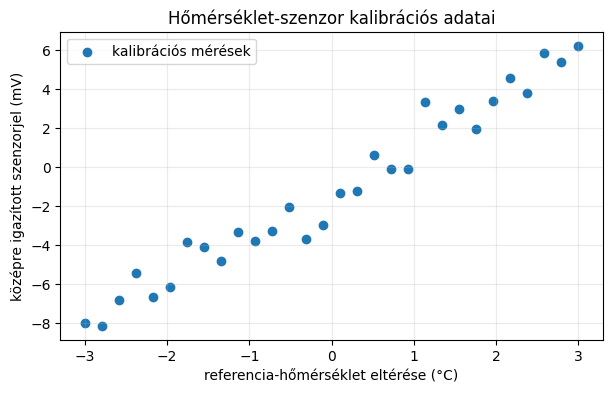

In [42]:
# Mesterséges kalibrációs adatok: a valódi kapcsolat közelítőleg y = 2.5x - 1.
x_simple = np.linspace(-3, 3, 30)
y_simple = 2.5 * x_simple - 1.0 + np.random.normal(0, 1.0, x_simple.shape)

plt.figure(figsize=(7, 4))
plt.scatter(x_simple, y_simple, color="tab:blue", label="kalibrációs mérések")
plt.xlabel("referencia-hőmérséklet eltérése (°C)")
plt.ylabel("középre igazított szenzorjel (mV)")
plt.title("Hőmérséklet-szenzor kalibrációs adatai")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Analitikus optimum NumPy-val

Mivel az MSE $w$ és $b$ szerint konvex másodfokú függvény, a minimum ott található, ahol mindkét parciális derivált nulla:

$$\frac{\partial L}{\partial w}=\frac{2}{n}\sum_i x_i(wx_i+b-y_i)=0,$$

$$\frac{\partial L}{\partial b}=\frac{2}{n}\sum_i(wx_i+b-y_i)=0.$$

Ez a két egyenlet a **normálegyenlethez** vezet. Mátrixos alakban $X\theta\approx y$, ahol az első oszlop az $x$ értékeket, a második csupa egyest tartalmaz, és $\theta=[w,b]^T$. A `np.linalg.lstsq` stabilan megoldja ezt a legkisebb négyzetes problémát.

Analitikus megoldás: w = 2.330, b = -1.188
MSE = 0.691


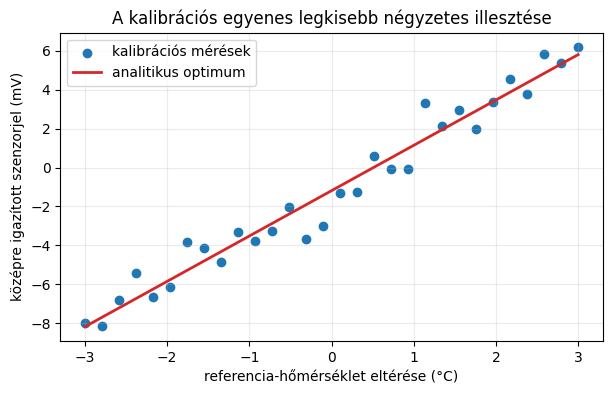

In [43]:
# Az (30,) x vektor mellé egyeseket teszünk: (30,) -> (30, 2).
# Az első oszlop a meredekséghez, a második a tengelymetszethez tartozik.
X_design = np.column_stack([x_simple, np.ones_like(x_simple)])
w_numpy, b_numpy = np.linalg.lstsq(X_design, y_simple, rcond=None)[0]  # (30, 2) és (30,) -> 2 paraméter
y_numpy = w_numpy * x_simple + b_numpy  # (30,) predikció
mse_numpy = np.mean((y_numpy - y_simple) ** 2)

print(f"Analitikus megoldás: w = {w_numpy:.3f}, b = {b_numpy:.3f}")
print(f"MSE = {mse_numpy:.3f}")

plt.figure(figsize=(7, 4))
plt.scatter(x_simple, y_simple, color="tab:blue", label="kalibrációs mérések")
plt.plot(x_simple, y_numpy, color="tab:red", linewidth=2, label="analitikus optimum")
plt.xlabel("referencia-hőmérséklet eltérése (°C)")
plt.ylabel("középre igazított szenzorjel (mV)")
plt.title("A kalibrációs egyenes legkisebb négyzetes illesztése")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

### Rövid bevezetés a PyTorch tenzorokba

A PyTorch alapvető adatszerkezete a [`torch.Tensor`](https://pytorch.org/docs/stable/tensors.html). A tenzor egy többdimenziós számtömb, amely hasonlít a NumPy tömbhöz, de képes GPU-n futni és automatikus deriválást használni.

A legfontosabb tulajdonságok:

- `shape`: az egyes dimenziók mérete;
- `dtype`: az elemek adattípusa;
- `device`: CPU vagy GPU tárolja-e az adatot;
- `requires_grad`: kell-e gradienst számítani a tenzor szerint.

A neurális hálók rétegei általában kétdimenziós bemenetet várnak: `(minták száma, jellemzők száma)`. A mostani regresszióban 30 minta és mintánként 1 jellemző van, ezért az elvárt alak `(30, 1)`.

In [44]:
# Egy egydimenziós NumPy tömbből 30 elemű, float32 PyTorch tenzor lesz: (30,).
x_tensor_1d = torch.tensor(x_simple, dtype=torch.float32)
print("Alak:", x_tensor_1d.shape)
print("Adattípus:", x_tensor_1d.dtype)
print("Eszköz:", x_tensor_1d.device)
print("Első három elem:", x_tensor_1d[:3])

# A reshape egy jellemzőoszlopot készít: (30,) -> (30, 1).
x_t = x_tensor_1d.reshape(-1, 1)
y_t = torch.tensor(y_simple, dtype=torch.float32).reshape(-1, 1)  # (30,) -> (30, 1)
print("Modellbemenet alakja:", x_t.shape)
print("Célérték alakja:", y_t.shape)

# A tanulható paraméterek skalár tenzorok; az autograd követi a rajtuk végzett műveleteket.
w_example = torch.tensor(0.0, requires_grad=True)
print("Tanulható paraméter:", w_example, "| requires_grad =", w_example.requires_grad)

# CPU-n a tenzor és a NumPy tömb között mindkét irányban egyszerű az átalakítás.
x_back_to_numpy = x_t.numpy()  # (30, 1) alakú NumPy tömb
print("Visszaalakított típus és alak:", type(x_back_to_numpy), x_back_to_numpy.shape)

Alak: torch.Size([30])
Adattípus: torch.float32
Eszköz: cpu
Első három elem: tensor([-3.0000, -2.7931, -2.5862])
Modellbemenet alakja: torch.Size([30, 1])
Célérték alakja: torch.Size([30, 1])
Tanulható paraméter: tensor(0., requires_grad=True) | requires_grad = True
Visszaalakított típus és alak: <class 'numpy.ndarray'> (30, 1)


### Ugyanez gradiens módszerrel PyTorchban

Nagyobb modelleknél az analitikus megoldás gyakran túl drága vagy nem is létezik zárt alakban. Ekkor iteratívan haladunk a veszteség negatív gradiense felé:

$$\theta_{t+1}=\theta_t-\eta\nabla_\theta L,$$

ahol $\eta$ a tanulási ráta. A PyTorch automatikus deriválása kiszámítja a gradienseket a `loss.backward()` híváskor.

Dokumentáció:

- [`torch.Tensor.backward`](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html)
- [`torch.optim.SGD`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html)
- [`torch.nn.MSELoss`](https://pytorch.org/docs/stable/generated/torch.nn.MSELoss.html)

Gradiens módszer: w = 2.330, b = -1.188


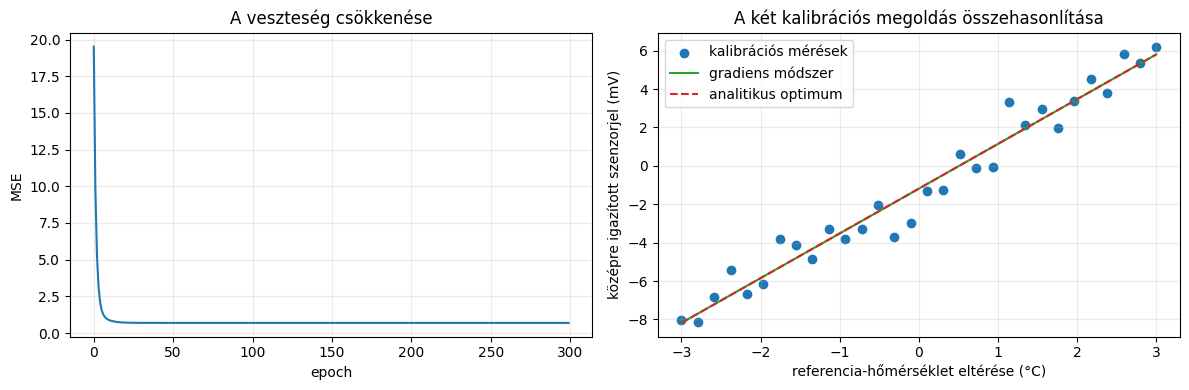

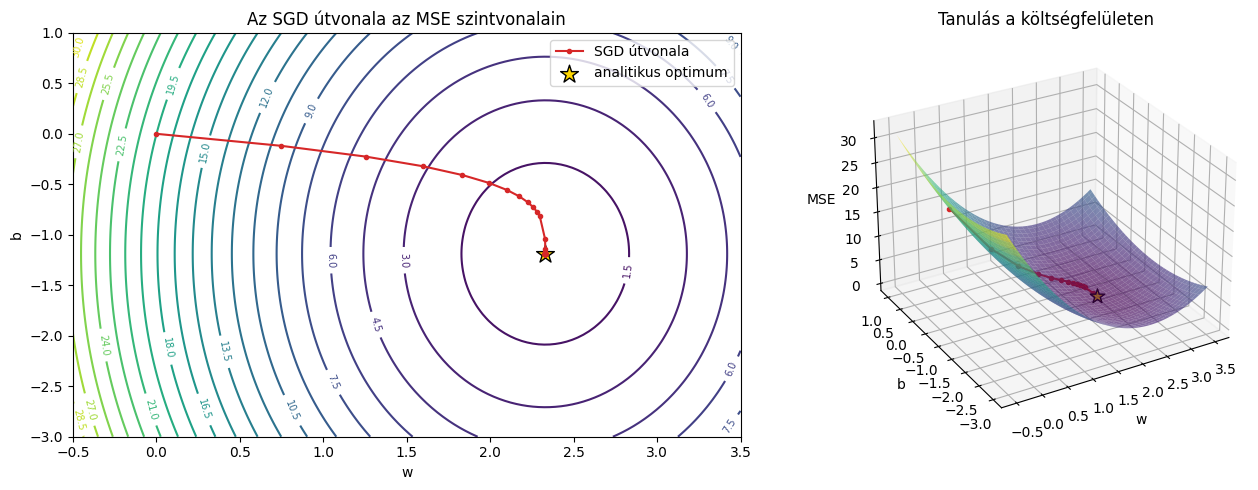

In [72]:
# A két skalár most tanulható paraméter; kezdetben szándékosan nullák.
w = torch.zeros(1, requires_grad=True)  # (1,)
b = torch.zeros(1, requires_grad=True)  # (1,)
criterion_mse = nn.MSELoss()
optimizer = torch.optim.SGD([w, b], lr=0.05)
loss_history = []
w_history = []
b_history = []

for epoch in range(300):
    # Broadcasting: (1,) * (30, 1) + (1,) -> 30 darab predikció, alakja (30, 1).
    y_hat = w * x_t + b
    loss = criterion_mse(y_hat, y_t)  # (30, 1) és (30, 1) -> skalár veszteség

    # A frissítés előtti pontokat mentjük, hogy lássuk az optimalizálás útvonalát.
    w_history.append(w.item())
    b_history.append(b.item())
    loss_history.append(loss.item())

    # A korábbi gradienseket törölni kell, mert a PyTorch összeadná őket.
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f"Gradiens módszer: w = {w.item():.3f}, b = {b.item():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(loss_history)
axes[0].set(xlabel="epoch", ylabel="MSE", title="A veszteség csökkenése")
axes[0].grid(alpha=0.25)
axes[1].scatter(x_simple, y_simple, color="tab:blue", label="kalibrációs mérések")
axes[1].plot(x_simple, (w.detach() * x_t + b.detach()).numpy(), color="tab:green", label="gradiens módszer")
axes[1].plot(x_simple, y_numpy, "--", color="tab:red", label="analitikus optimum")
axes[1].set(
    xlabel="referencia-hőmérséklet eltérése (°C)",
    ylabel="középre igazított szenzorjel (mV)",
    title="A két kalibrációs megoldás összehasonlítása",
)
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

# Az MSE-felületet a két tanulható paraméter, w és b rácsán értékeljük ki.
w_grid = np.linspace(-0.5, 3.5, 120)
b_grid = np.linspace(-3.0, 1.0, 120)
W_grid, B_grid = np.meshgrid(w_grid, b_grid)
prediction_grid = (
    W_grid[..., None] * x_simple[None, None, :]
    + B_grid[..., None]
)  # (120, 120, 30)
loss_surface = np.mean(
    (prediction_grid - y_simple[None, None, :]) ** 2, axis=2
)  # (120, 120)

# Az első pontokat sűrűbben, később minden tizedik pontot mutatjuk.
path_indices = np.unique(np.r_[np.arange(12), np.arange(20, 300, 10), 299])
path_w = np.array(w_history)[path_indices]
path_b = np.array(b_history)[path_indices]
path_loss = np.array(loss_history)[path_indices]

fig = plt.figure(figsize=(14, 5))
contour_axis = fig.add_subplot(1, 2, 1)
contours = contour_axis.contour(W_grid, B_grid, loss_surface, levels=25)
contour_axis.clabel(contours, inline=True, fontsize=7)
contour_axis.plot(path_w, path_b, "o-", color="tab:red", markersize=3, label="SGD útvonala")
contour_axis.scatter(w_numpy, b_numpy, marker="*", s=180, color="gold", edgecolor="black", label="analitikus optimum")
contour_axis.set(xlabel="w", ylabel="b", title="Az SGD útvonala az MSE szintvonalain")
contour_axis.legend()

surface_axis = fig.add_subplot(1, 2, 2, projection="3d")
surface_axis.plot_surface(W_grid, B_grid, loss_surface, cmap="viridis", alpha=0.65, edgecolor="none")
surface_axis.plot(path_w, path_b, path_loss, "o-", color="tab:red", markersize=3, label="SGD útvonala")
surface_axis.scatter(w_numpy, b_numpy, mse_numpy, marker="*", s=120, color="gold", edgecolor="black")
surface_axis.set(xlabel="w", ylabel="b", zlabel="MSE", title="Tanulás a költségfelületen")
surface_axis.view_init(elev=28, azim=-120)
plt.tight_layout()
plt.show()

## 1.2 Lineáris regresszió több tanulható paraméterrel

**Valós példa – egy ipari gép energiaigényének becslése.** A célváltozó a következő időablak standardizált energiafogyasztása. A három bemeneti jellemző a gép terhelése, a környezeti hőmérséklet és a motor fordulatszáma. A jellemzőket standardizáltuk, ezért a nulla az átlagos üzemi állapotot jelenti, a negatív érték pedig nem fizikailag negatív mennyiség, hanem átlag alatti érték.

Most minden mintához három jellemző tartozik. A modell

$$\hat{y}=w_1x_1+w_2x_2+w_3x_3+b=\mathbf{x}^T\mathbf{w}+b.$$

A **vektorizáció** azt jelenti, hogy nem írunk külön képletet minden mintára és jellemzőre. Az egész adathalmaz predikciója egyetlen mátrixszorzás:

$$\hat{\mathbf{y}}=X\mathbf{w}+b.$$

Először itt is megvizsgáljuk az adatokat. Három dimenziót nehéz egyszerre ábrázolni, ezért mindegyik jellemző és a célváltozó kapcsolatát külön grafikonon nézzük meg.

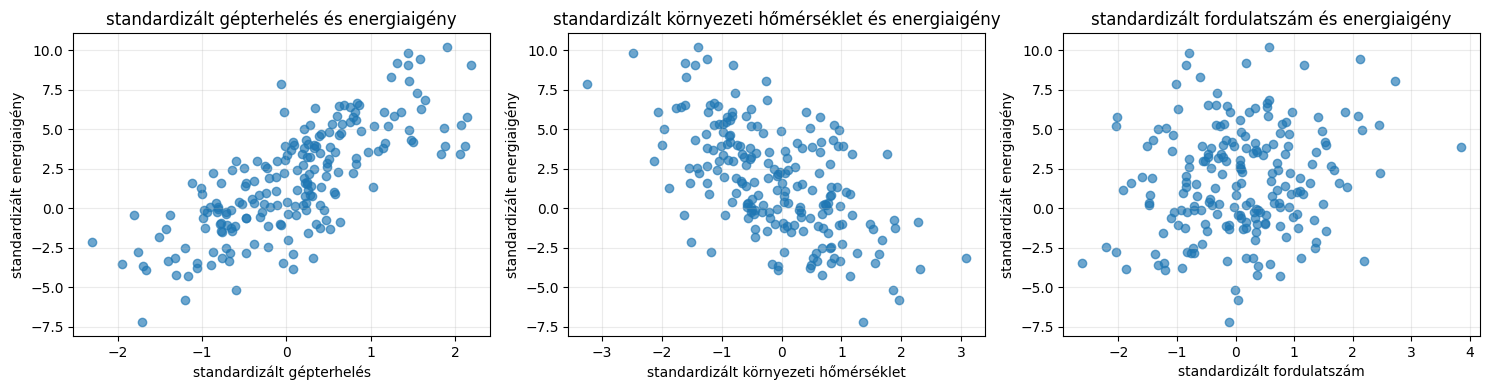

In [46]:
n_samples = 200
X_multi = np.random.normal(size=(n_samples, 3)).astype(np.float32)
true_weights = np.array([3.0, -2.0, 0.5], dtype=np.float32)
y_multi = X_multi @ true_weights + 1.2 + np.random.normal(0, 0.5, n_samples)
y_multi = y_multi.astype(np.float32)

feature_names = [
    "standardizált gépterhelés",
    "standardizált környezeti hőmérséklet",
    "standardizált fordulatszám",
]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for feature_index, axis in enumerate(axes):
    axis.scatter(X_multi[:, feature_index], y_multi, alpha=0.65)
    axis.set(
        xlabel=feature_names[feature_index],
        ylabel="standardizált energiaigény",
        title=f"{feature_names[feature_index]} és energiaigény",
    )
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

A [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) réteg pontosan az $XW^T+b$ vektorizált műveletet valósítja meg. A három bemeneti jellemzőhöz három súly, az egy kimenethez pedig egy bias tartozik. A tanulási ciklus ugyanaz marad, mint az egyszerű esetben.

Valódi súlyok:  [ 3.  -2.   0.5]
Tanult súlyok:  [ 2.957 -2.039  0.502]
Valódi bias: 1.200, tanult bias: 1.194


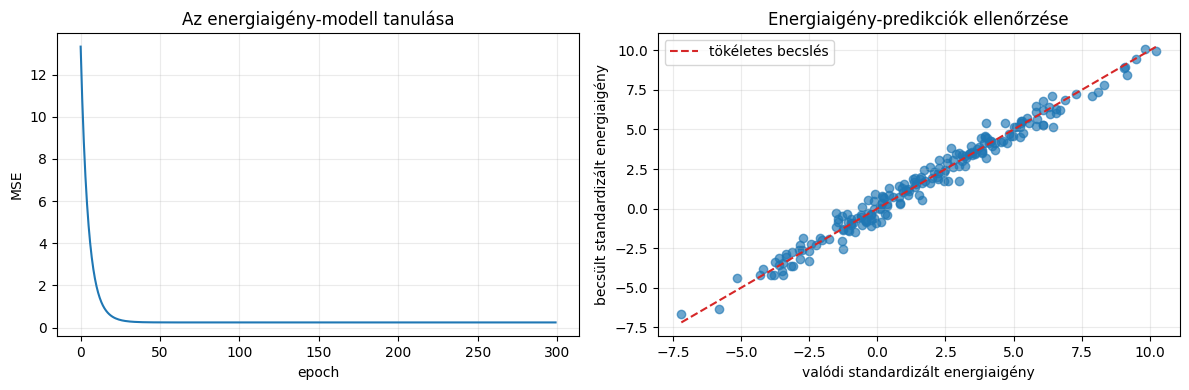

In [47]:
# A NumPy jellemzőmátrix alakja (200, 3), a célvektoré (200,).
X_multi_t = torch.from_numpy(X_multi)  # (200, 3), soronként egy minta
# A lineáris réteg kimenetéhez igazítjuk a célt: (200,) -> (200, 1).
y_multi_t = torch.from_numpy(y_multi).reshape(-1, 1)

# A réteg a három jellemzőből mintánként egy értéket számít: (200, 3) -> (200, 1).
multi_model = nn.Linear(in_features=3, out_features=1)
multi_optimizer = torch.optim.SGD(multi_model.parameters(), lr=0.05)
multi_losses = []

for epoch in range(300):
    predictions = multi_model(X_multi_t)  # (200, 1)
    loss = criterion_mse(predictions, y_multi_t)  # két (200, 1) tenzor -> skalár
    multi_optimizer.zero_grad()
    loss.backward()
    multi_optimizer.step()
    multi_losses.append(loss.item())

# (1, 3) -> (3,), így a három tanult súly egyszerű vektorként jelenik meg.
learned_weights = multi_model.weight.detach().squeeze().numpy()
learned_bias = multi_model.bias.detach().item()
print("Valódi súlyok: ", true_weights)
print("Tanult súlyok: ", np.round(learned_weights, 3))
print(f"Valódi bias: 1.200, tanult bias: {learned_bias:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(multi_losses)
axes[0].set(xlabel="epoch", ylabel="MSE", title="Az energiaigény-modell tanulása")
axes[0].grid(alpha=0.25)
# A (200, 1) predikciót (200,) vektorrá alakítjuk az ábrázoláshoz.
predictions_numpy = multi_model(X_multi_t).detach().squeeze().numpy()
axes[1].scatter(y_multi, predictions_numpy, alpha=0.65)
limits = [y_multi.min(), y_multi.max()]
axes[1].plot(limits, limits, "--", color="tab:red", label="tökéletes becslés")
axes[1].set(
    xlabel="valódi standardizált energiaigény",
    ylabel="becsült standardizált energiaigény",
    title="Energiaigény-predikciók ellenőrzése",
)
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

---

# 2. Osztályozás

Osztályozáskor nem folytonos értéket, hanem kategóriát becslünk. Bináris esetben legyen $y\in\{0,1\}$. A logisztikus regresszió először egy lineáris pontszámot, más néven **logitot** számít:

$$z=\mathbf{x}^T\mathbf{w}+b,$$

majd ezt a szigmoid függvény alakítja valószínűséggé:

$$P(y=1\mid\mathbf{x})=\sigma(z)=\frac{1}{1+e^{-z}}.$$

A modell az 1-es osztályt választja, ha a valószínűség legalább 0,5. Ez a $z=0$ egyenlet miatt mindig lineáris döntési határt jelent.

## 2.1 Logisztikus regresszió lineárisan szeparálható adatokon

**Valós példa – automatikus minőségellenőrzés.** Egy gyártósoron minden alkatrészhez két standardizált mérés tartozik: a rezgésszint és egy kamerás felületi hibapontszám. A jó és a hibás alkatrészek ebben az egyszerűsített esetben két jól elkülönülő tartományt alkotnak. Egy egyenes küszöb elegendő lehet a selejtek felismeréséhez.

Először rajzoljuk ki a két osztályt. A 0-s címke megfelelő, az 1-es címke hibás alkatrészt jelent.

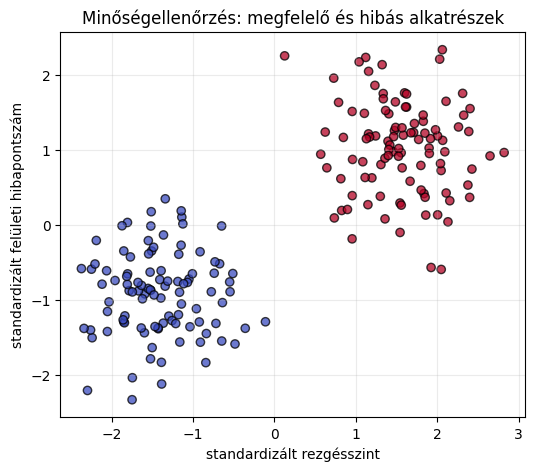

In [48]:
n_per_class = 100
class_0 = np.random.normal(loc=(-1.5, -1.0), scale=0.55, size=(n_per_class, 2))  # megfelelő alkatrészek
class_1 = np.random.normal(loc=(1.5, 1.0), scale=0.55, size=(n_per_class, 2))  # hibás alkatrészek
# A két osztályt egymás alá fűzzük: 2 x (100, 2) -> (200, 2).
X_separable = np.vstack([class_0, class_1]).astype(np.float32)
# Minden mintához egy címke tartozik: 2 x (100,) -> (200,).
y_separable = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)]).astype(np.float32)

plt.figure(figsize=(6, 5))
plt.scatter(X_separable[:, 0], X_separable[:, 1], c=y_separable, cmap="coolwarm", edgecolor="black", alpha=0.75)
plt.xlabel("standardizált rezgésszint")
plt.ylabel("standardizált felületi hibapontszám")
plt.title("Minőségellenőrzés: megfelelő és hibás alkatrészek")
plt.grid(alpha=0.25)
plt.show()

### Első próbálkozás: logisztikus regresszió MSE-veszteséggel

Kézenfekvő ötlet a regressziónál bevált MSE-t használni a szigmoid kimenete és a 0/1 címkék között:

$$L_{MSE}=\frac{1}{n}\sum_i\left(\sigma(z_i)-y_i\right)^2.$$

A lineáris regresszió MSE-vesztesége konvex a paraméterekben, mert egy affin függvény négyzetes hibáját minimalizáljuk. A logisztikus regresszióban azonban a szigmoid és a négyzetes hiba összetétele általában **nem konvex**. Emiatt a veszteségfelületnek lehetnek negatív görbületű, lapos részei, és a gradiens módszer viselkedése erősen függhet a kezdeti paraméterektől.

Ez futtatható, tehát az MSE **nem tiltott** osztályozásnál. A szigmoid deriváltja azonban közel nulla, amikor a logit nagy abszolút értékű. Ha a modell ilyenkor magabiztosan téved, az MSE gradiense is nagyon kicsi lehet, ezért a tanulás elakadhat.

A jelenséget szándékosan rossz, telített kezdeti súlyokkal tesszük láthatóvá. Később pontosan ugyanebből az állapotból indítjuk a BCE-változatot.

Kezdeti MSE-gradiens normája: 8.46e-05
MSE utáni pontosság: 0.0%


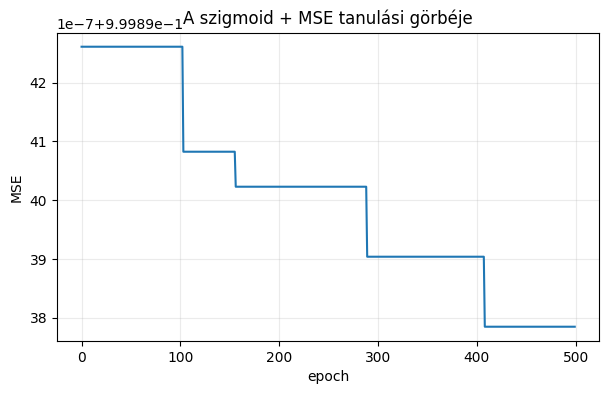

In [49]:
# (200, 2) jellemzőmátrix és (200,) bináris címkevektor.
X_sep_t = torch.from_numpy(X_separable)
y_sep_t = torch.from_numpy(y_separable)

mse_logistic_model = nn.Linear(2, 1)
with torch.no_grad():
    # Mindkét veszteség ugyanebből a telített, rossz állapotból indul majd.
    mse_logistic_model.weight.copy_(torch.tensor([[-8.0, -8.0]]))  # (1, 2)
    mse_logistic_model.bias.zero_()  # (1,)

initial_weight = mse_logistic_model.weight.detach().clone()
initial_bias = mse_logistic_model.bias.detach().clone()
mse_optimizer = torch.optim.SGD(mse_logistic_model.parameters(), lr=0.1)
mse_loss_function = nn.MSELoss()
mse_classification_losses = []
mse_initial_gradient_norm = None

for epoch in range(500):
    logits = mse_logistic_model(X_sep_t).squeeze(1)  # (200, 2) -> (200, 1) -> (200,)
    probabilities = torch.sigmoid(logits)  # (200,) logitból (200,) valószínűség
    loss = mse_loss_function(probabilities, y_sep_t)  # két (200,) vektor -> skalár
    mse_optimizer.zero_grad()
    loss.backward()
    if epoch == 0:
        mse_initial_gradient_norm = mse_logistic_model.weight.grad.norm().item()
    mse_optimizer.step()
    mse_classification_losses.append(loss.item())

with torch.no_grad():
    mse_predictions = (torch.sigmoid(mse_logistic_model(X_sep_t).squeeze(1)) >= 0.5).float()
    mse_accuracy = (mse_predictions == y_sep_t).float().mean().item()

print(f"Kezdeti MSE-gradiens normája: {mse_initial_gradient_norm:.2e}")
print(f"MSE utáni pontosság: {100 * mse_accuracy:.1f}%")

plt.figure(figsize=(7, 4))
plt.plot(mse_classification_losses)
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("A szigmoid + MSE tanulási görbéje")
plt.grid(alpha=0.25)
plt.show()

### Miért jobb választás a bináris keresztentrópia?

A bináris keresztentrópia (BCE) a helyes osztályhoz rendelt valószínűséget jutalmazza:

$$L_{BCE}=-\frac{1}{n}\sum_i\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right].$$

Lineáris logit, $z=\mathbf{x}^T\mathbf{w}+b$ mellett ugyanez mintánként

$$\ell(z,y)=\log(1+e^z)-yz.$$

Ez **konvex** a modell paramétereiben: a görbület nemnegatív, ezért minden lokális minimum globális minimum. Szigmoid kimenet esetén a BCE logit szerinti deriváltja egyszerűen $\sigma(z)-y$. Magabiztos, de hibás predikciónál ez nagy marad, ezért a modell képes elmozdulni a rossz állapotból. Az MSE deriváltjában ezzel szemben megjelenik a szigmoid kis deriváltja is, ami telített állapotban lelassítja a tanulást.

Fontos pontosítás: tökéletesen szeparálható adatokon regularizáció nélkül a BCE egyre kisebb lehet a súlyok növelésével, ezért nem feltétlenül van véges paraméterű minimuma. A konvexitás azt garantálja, hogy nincsenek rossz lokális minimumok; a véges optimumot például L2-regularizáció biztosíthatja.

A numerikusan stabil [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) egyetlen műveletben egyesíti a szigmoidot és a BCE-t. Tanításkor ezért nyers logitokat adunk neki; külön szigmoidot csak a valószínűségek értelmezésekor használunk.

#### A konvexitás szemléltetése egy paraméterirány mentén

Egy többdimenziós veszteségfelületet nehéz közvetlenül ábrázolni, ezért a súlyvektort egy rögzített irányban mozgatjuk: $\mathbf{w}=\alpha\mathbf{d}$. Ez a teljes felület egy egydimenziós metszete.

- Ha egy függvény konvex, akkor minden ilyen egyenes menti metszete konvex, vagyis a második deriváltja nemnegatív.
- Ha akár egy metszeten negatív második deriváltat találunk, a teljes függvény nem konvex.

Az alábbi ábra ugyanazon adatokon mutatja a két veszteséget és görbületüket.

Legkisebb BCE-görbület: 1.136e-05
Legkisebb MSE-görbület: -3.540e-01


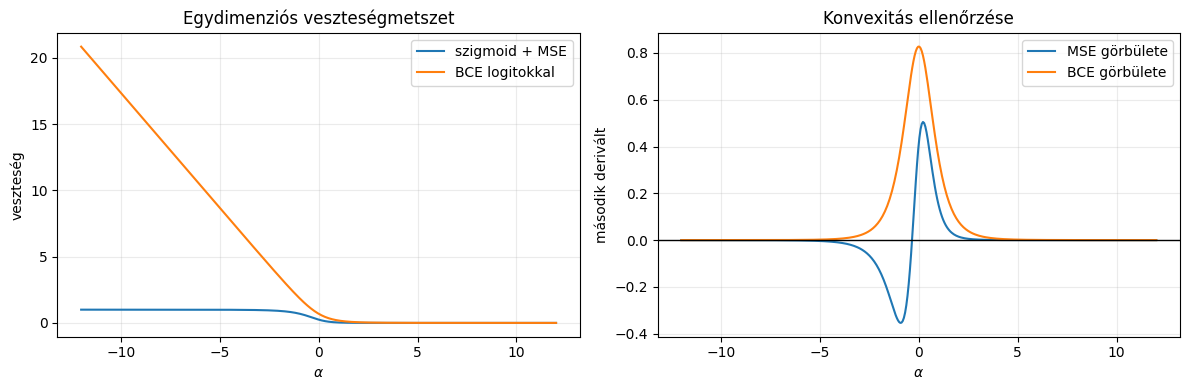

In [50]:
# A szeparáló irány egységvektora; csak az alpha skálaparamétert változtatjuk.
direction = torch.tensor([1.0, 1.0])
direction = direction / direction.norm()  # (2,)
alphas = torch.linspace(-12, 12, 400)  # (400,)
scores = X_sep_t @ direction  # (200, 2) @ (2,) -> (200,)

# Minden sor egy alpha értékhez, minden oszlop egy mintához tartozik: (400, 200).
logit_grid = alphas[:, None] * scores[None, :]
probability_grid = torch.sigmoid(logit_grid)
target_grid = y_sep_t[None, :]  # (1, 200), broadcastinggal (400, 200)

mse_slice = ((probability_grid - target_grid) ** 2).mean(dim=1)  # (400,)
bce_slice = nn.functional.binary_cross_entropy_with_logits(
    logit_grid, target_grid.expand_as(logit_grid), reduction="none"
).mean(dim=1)  # (400,)

# Analitikus második derivált alpha szerint, mintánként átlagolva.
sigmoid_derivative = probability_grid * (1 - probability_grid)
bce_curvature = (sigmoid_derivative * scores[None, :] ** 2).mean(dim=1)
mse_curvature = (
    2 * scores[None, :] ** 2
    * (
        sigmoid_derivative ** 2
        + (probability_grid - target_grid)
        * sigmoid_derivative
        * (1 - 2 * probability_grid)
    )
).mean(dim=1)

print(f"Legkisebb BCE-görbület: {bce_curvature.min().item():.3e}")
print(f"Legkisebb MSE-görbület: {mse_curvature.min().item():.3e}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(alphas, mse_slice, label="szigmoid + MSE")
axes[0].plot(alphas, bce_slice, label="BCE logitokkal")
axes[0].set(xlabel=r"$\alpha$", ylabel="veszteség", title="Egydimenziós veszteségmetszet")
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(alphas, mse_curvature, label="MSE görbülete")
axes[1].plot(alphas, bce_curvature, label="BCE görbülete")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(xlabel=r"$\alpha$", ylabel="második derivált", title="Konvexitás ellenőrzése")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

Kezdeti BCE-gradiens normája: 1.78e+00
BCE utáni pontosság: 100.0%
A BCE kezdeti gradiense 20986-szer nagyobb az MSE gradiensénél.


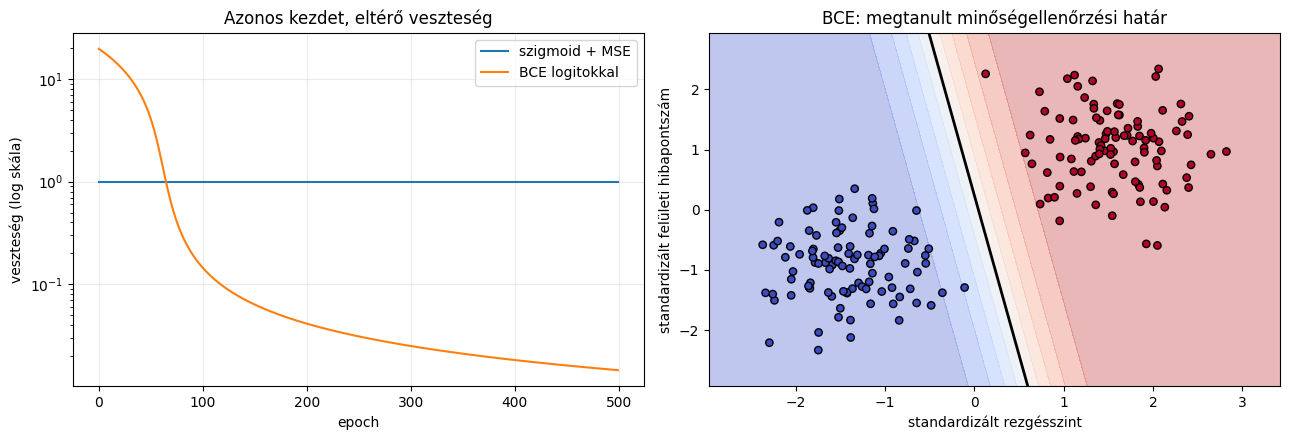

In [ ]:
def train_binary_model(model, X, y, epochs=500, learning_rate=0.05, weight_decay=0.0):
    """Bináris osztályozó tanítása és a veszteségek visszaadása."""
    loss_function = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(
        model.parameters(), lr=learning_rate, weight_decay=weight_decay
    )
    losses = []
    for _ in range(epochs):
        logits = model(X).squeeze(1)  # (N, 2) -> (N, 1) -> (N,)
        loss = loss_function(logits, y)  # két (N,) vektor -> skalár
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


def binary_accuracy(model, X, y):
    """A 0,5 küszöbbel kapott bináris pontosság."""
    with torch.no_grad():
        logits = model(X).squeeze(1)  # (N, 1) -> (N,)
        predictions = (torch.sigmoid(logits) >= 0.5).float()  # (N,)
    return (predictions == y).float().mean().item()


def plot_decision_surface(model, X, y, title, axis=None, xlabel="x1", ylabel="x2"):
    """A modell döntési tartományának és adatpontjainak ábrázolása."""
    if axis is None:
        _, axis = plt.subplots(figsize=(6, 5))
    x1 = np.linspace(X[:, 0].min() - 0.6, X[:, 0].max() + 0.6, 180)
    x2 = np.linspace(X[:, 1].min() - 0.6, X[:, 1].max() + 0.6, 180)
    grid_x1, grid_x2 = np.meshgrid(x1, x2)  # két (180, 180) koordinátarács
    grid = torch.tensor(
        np.c_[grid_x1.ravel(), grid_x2.ravel()], dtype=torch.float32
    )  # 32 400 rácspont, alak: (32400, 2)
    model_device = next(model.parameters()).device
    with torch.no_grad():
        grid_logits = model(grid.to(model_device)).squeeze(1)  # (32400,)
        probabilities = torch.sigmoid(grid_logits).cpu().numpy()
    probabilities = probabilities.reshape(grid_x1.shape)  # (32400,) -> (180, 180)
    axis.contourf(grid_x1, grid_x2, probabilities, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
    axis.contour(grid_x1, grid_x2, probabilities, levels=[0.5], colors="black", linewidths=2)
    axis.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", s=28)
    axis.set(xlabel=xlabel, ylabel=ylabel, title=title)


# A BCE-modell ugyanazokból a súlyokból indul, mint az MSE-modell.
logistic_model = nn.Linear(2, 1)
with torch.no_grad():
    logistic_model.weight.copy_(initial_weight)
    logistic_model.bias.copy_(initial_bias)

bce_optimizer = torch.optim.SGD(logistic_model.parameters(), lr=0.1)
bce_loss_function = nn.BCEWithLogitsLoss()
bce_losses = []
bce_initial_gradient_norm = None

for epoch in range(500):
    logits = logistic_model(X_sep_t).squeeze(1)  # (200, 2) -> (200,)
    loss = bce_loss_function(logits, y_sep_t)  # két (200,) vektor -> skalár
    bce_optimizer.zero_grad()
    loss.backward()
    if epoch == 0:
        bce_initial_gradient_norm = logistic_model.weight.grad.norm().item()
    bce_optimizer.step()
    bce_losses.append(loss.item())

bce_accuracy = binary_accuracy(logistic_model, X_sep_t, y_sep_t)
print(f"Kezdeti BCE-gradiens normája: {bce_initial_gradient_norm:.2e}")
print(f"BCE utáni pontosság: {100 * bce_accuracy:.1f}%")
print(f"A BCE kezdeti gradiense {bce_initial_gradient_norm / mse_initial_gradient_norm:.0f}-szer nagyobb az MSE gradiensénél.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(mse_classification_losses, label="szigmoid + MSE")
axes[0].plot(bce_losses, label="BCE logitokkal")
axes[0].set_yscale("log")
axes[0].set(xlabel="epoch", ylabel="veszteség (log skála)", title="Azonos kezdet, eltérő veszteség")
axes[0].legend()
axes[0].grid(alpha=0.25)
plot_decision_surface(
    logistic_model,
    X_separable,
    y_separable,
    "BCE: megtanult minőségellenőrzési határ",
    axes[1],
    xlabel="standardizált rezgésszint",
    ylabel="standardizált felületi hibapontszám",
)
plt.tight_layout()
plt.show()

## 2.2 Amikor az adatok nem lineárisan szeparálhatók

**Valós példa – munkavédelmi biztonsági zóna.** Egy robotcella padlóján egy személy helyzetét két koordináta írja le. A belső kör a robothoz közeli, tiltott zóna, a külső gyűrű pedig a biztonságosabb tartomány mintáit tartalmazza. A kockázatot itt nem önmagában a vízszintes vagy függőleges koordináta, hanem a robot középpontjától mért távolság határozza meg.

Ezért nincs olyan egyenes, amely a két osztályt minden irányban szétválasztaná: ugyanazon irány mentén lehet közeli és távoli pont is. Az adatgeneráló függvényt később is használjuk, hogy ugyanazon a problémán hasonlíthassuk össze a modelleket.

A modell illesztése előtt ismét az adatokat rajzoljuk ki. A 0-s címke a belső tiltott zónát, az 1-es címke a külső tartományt jelöli.

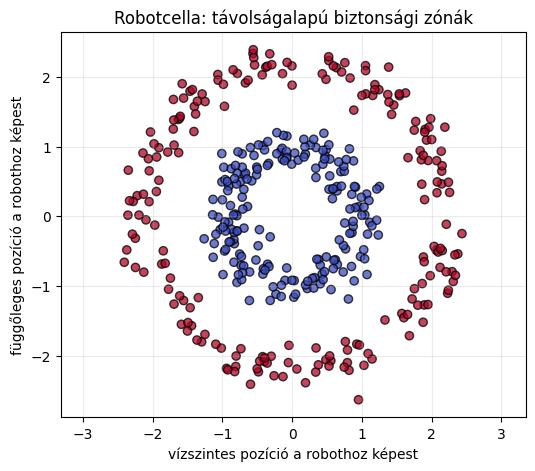

In [52]:
def make_rings(n_samples, noise=0.10, seed=0):
    """Belső tiltott zóna és külső biztonsági tartomány előállítása."""
    generator = np.random.default_rng(seed)
    labels = generator.integers(0, 2, n_samples)  # (N,) bináris címkevektor
    angles = generator.uniform(0, 2 * np.pi, n_samples)  # (N,) szögvektor
    radii = np.where(labels == 0, 1.0, 2.2) + generator.normal(0, noise, n_samples)  # (N,)
    # A polárkoordinátákból két Descartes-koordináta lesz: két (N,) vektor -> (N, 2).
    features = np.column_stack([radii * np.cos(angles), radii * np.sin(angles)])
    return features.astype(np.float32), labels.astype(np.float32)

X_rings, y_rings = make_rings(400, noise=0.16, seed=1)  # (400, 2), illetve (400,)

plt.figure(figsize=(6, 5))
plt.scatter(X_rings[:, 0], X_rings[:, 1], c=y_rings, cmap="coolwarm", edgecolor="black", alpha=0.75)
plt.xlabel("vízszintes pozíció a robothoz képest")
plt.ylabel("függőleges pozíció a robothoz képest")
plt.title("Robotcella: távolságalapú biztonsági zónák")
plt.axis("equal")
plt.grid(alpha=0.25)
plt.show()

Logisztikus regresszió pontossága: 47.7%


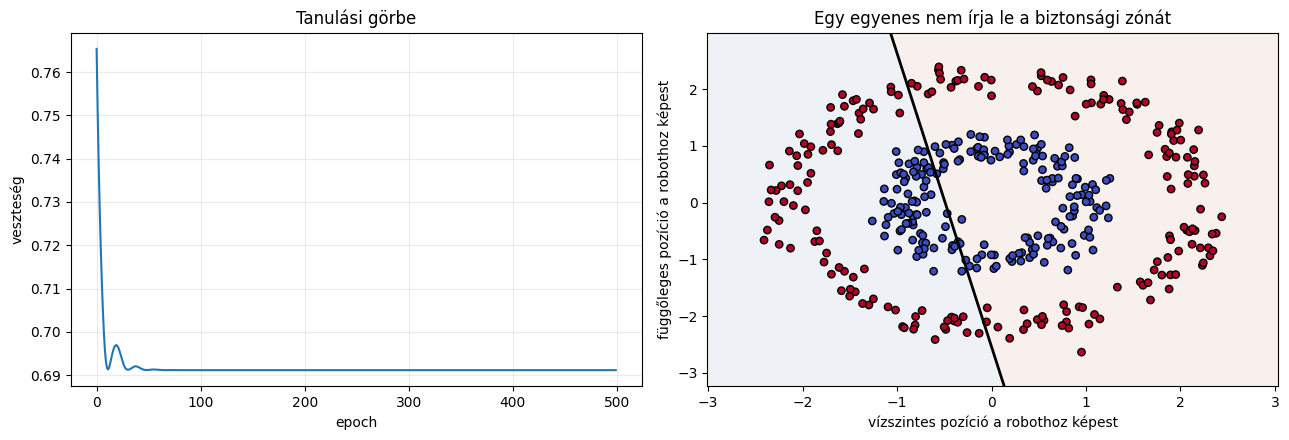

In [53]:
# A NumPy tömbök alakja megmarad: X (400, 2), y (400,).
X_rings_t = torch.from_numpy(X_rings)
y_rings_t = torch.from_numpy(y_rings)

# Két pozíciókoordinátából mintánként egy logit készül: (400, 2) -> (400, 1).
rings_logistic_model = nn.Linear(2, 1)
rings_logistic_losses = train_binary_model(
    rings_logistic_model, X_rings_t, y_rings_t, epochs=500
)
rings_logistic_accuracy = binary_accuracy(rings_logistic_model, X_rings_t, y_rings_t)

print(f"Logisztikus regresszió pontossága: {100 * rings_logistic_accuracy:.1f}%")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(rings_logistic_losses)
axes[0].set(xlabel="epoch", ylabel="veszteség", title="Tanulási görbe")
axes[0].grid(alpha=0.25)
plot_decision_surface(
    rings_logistic_model,
    X_rings,
    y_rings,
    "Egy egyenes nem írja le a biztonsági zónát",
    axes[1],
    xlabel="vízszintes pozíció a robothoz képest",
    ylabel="függőleges pozíció a robothoz képest",
)
plt.tight_layout()
plt.show()

---

# 3. Egyrétegű neurális hálózatok

Itt az „egyrétegű neurális hálózat” egy **rejtett réteget** jelent. A modell két lineáris transzformáció közé nemlineáris aktivációt tesz:

$$\mathbf{h}=\tanh(XW_1^T+\mathbf{b}_1),$$

$$\mathbf{z}=\mathbf{h}W_2^T+b_2.$$

A rejtett reprezentáció miatt a végső lineáris réteg már nem az eredeti síkon húz egyenest. Nemlineáris döntési határ jöhet létre.

Használt modulok:

- [`torch.nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html): rétegek sorba kapcsolása;
- [`torch.nn.Tanh`](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html): nemlineáris aktiváció;
- [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html): affin transzformáció.

## 3.1 Egy rejtett réteg a robotcella biztonsági zónáin

Az adatokat az előző ábrán már megvizsgáltuk. Most ugyanazokat a pozíciómintákat használjuk, így a logisztikus regresszióval való összehasonlítás korrekt. A cél egy kör alakú tiltott zónához illeszkedő, nemlineáris döntési határ megtanulása.

Logisztikus regresszió: 47.7%
Egy rejtett réteg:      100.0%


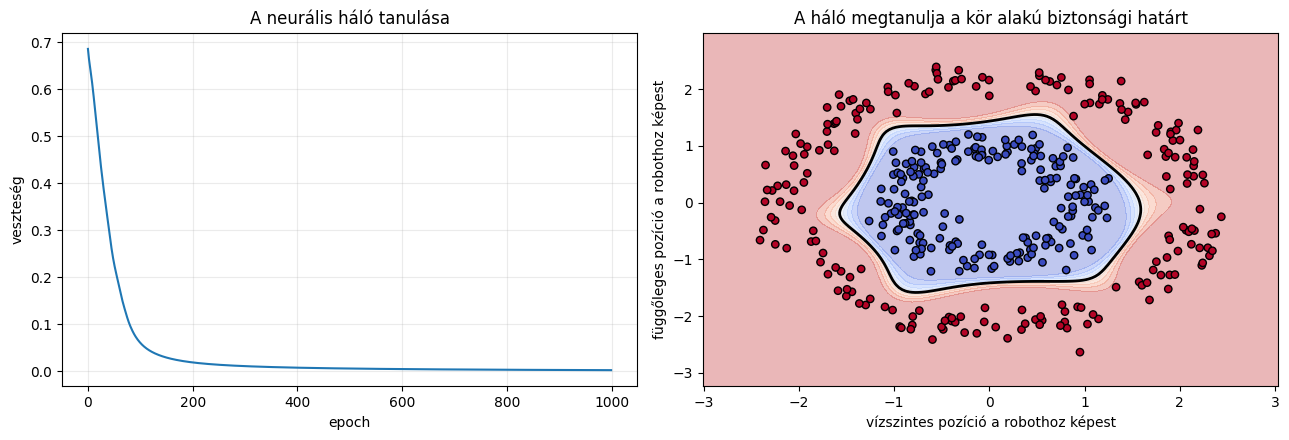

In [60]:
torch.manual_seed(42)
one_layer_model = nn.Sequential(
    nn.Linear(2, 8),  # (N, 2) bemenet -> (N, 8) rejtett reprezentáció
    nn.Tanh(),        # az alak változatlan marad: (N, 8)
    nn.Linear(8, 1),  # (N, 8) -> (N, 1) logit
)
one_layer_losses = train_binary_model(
    one_layer_model, X_rings_t, y_rings_t, epochs=1000, learning_rate=0.03
)
one_layer_accuracy = binary_accuracy(one_layer_model, X_rings_t, y_rings_t)

print(f"Logisztikus regresszió: {100 * rings_logistic_accuracy:.1f}%")
print(f"Egy rejtett réteg:      {100 * one_layer_accuracy:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(one_layer_losses)
axes[0].set(xlabel="epoch", ylabel="veszteség", title="A neurális háló tanulása")
axes[0].grid(alpha=0.25)
plot_decision_surface(
    one_layer_model,
    X_rings,
    y_rings,
    "A háló megtanulja a kör alakú biztonsági határt",
    axes[1],
    xlabel="vízszintes pozíció a robothoz képest",
    ylabel="függőleges pozíció a robothoz képest",
)
plt.tight_layout()
plt.show()

## 3.2 Túlillesztés és L2-regularizáció

A nagy kapacitású modell kevés, zajos adaton akár a hibás címkéket is megtanulhatja. Ezt nevezzük **túlillesztésnek**: a tanítási pontosság magas, de új, tiszta adatokon romlik a teljesítmény.

**Valós helyzet.** Egy új robotcella üzembe helyezésekor kezdetben csak kevés pozícióeseményt címkéztek. A címkék egy része hibás lehet pontatlan helymeghatározás vagy téves emberi annotáció miatt. A későbbi, nagyobb ellenőrző adathalmaz már pontosabban mutatja a valódi biztonsági zónát.

Ezért ugyanabból a biztonsági zóna problémából készítünk:

- egy kicsi tanítóhalmazt, amelyben néhány címkét szándékosan megfordítunk;
- egy nagy, tiszta teszthalmazt.

Először ezeket az adatokat is megjelenítjük.

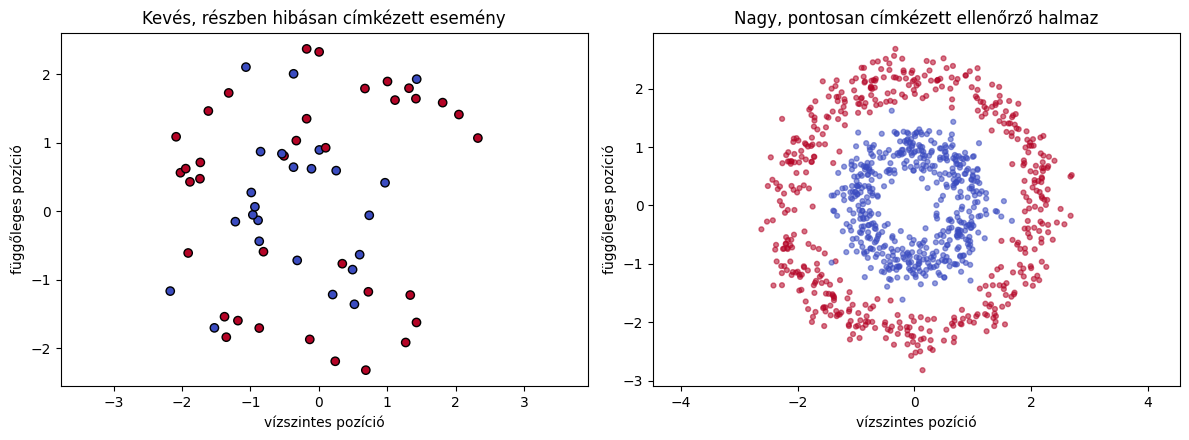

In [55]:
X_small_train, y_small_train = make_rings(60, noise=0.22, seed=10)  # (60, 2), (60,)
X_clean_test, y_clean_test = make_rings(1000, noise=0.22, seed=11)  # (1000, 2), (1000,)

# A tanítócímkék 20%-át megfordítjuk; az alak továbbra is (60,).
noise_generator = np.random.default_rng(12)
flipped_indices = noise_generator.choice(len(y_small_train), size=12, replace=False)  # (12,)
y_noisy_train = y_small_train.copy()
y_noisy_train[flipped_indices] = 1 - y_noisy_train[flipped_indices]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_small_train[:, 0], X_small_train[:, 1], c=y_noisy_train, cmap="coolwarm", edgecolor="black")
axes[0].set(
    xlabel="vízszintes pozíció",
    ylabel="függőleges pozíció",
    title="Kevés, részben hibásan címkézett esemény",
)
axes[0].axis("equal")
axes[1].scatter(X_clean_test[:, 0], X_clean_test[:, 1], c=y_clean_test, cmap="coolwarm", s=12, alpha=0.55)
axes[1].set(
    xlabel="vízszintes pozíció",
    ylabel="függőleges pozíció",
    title="Nagy, pontosan címkézett ellenőrző halmaz",
)
axes[1].axis("equal")
plt.tight_layout()
plt.show()

Az L2-regularizáció a nagy súlyokat bünteti:

$$L_{reg}=L_{adat}+\lambda\sum_j w_j^2.$$

Ez csökkenti a modell hajlamát arra, hogy nagyon éles, bonyolult döntési határral kövesse a zajt. A [`torch.optim.SGD`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) `weight_decay` paramétere L2-jellegű súlycsökkenést ad. Az összehasonlítás kedvéért a két háló azonos inicializált paraméterekből indul; csak a regularizáció erőssége különbözik.

Regularizáció nélkül     | tanító: 100.0% | teszt:  70.8%
L2-regularizációval      | tanító:  81.7% | teszt:  87.1%


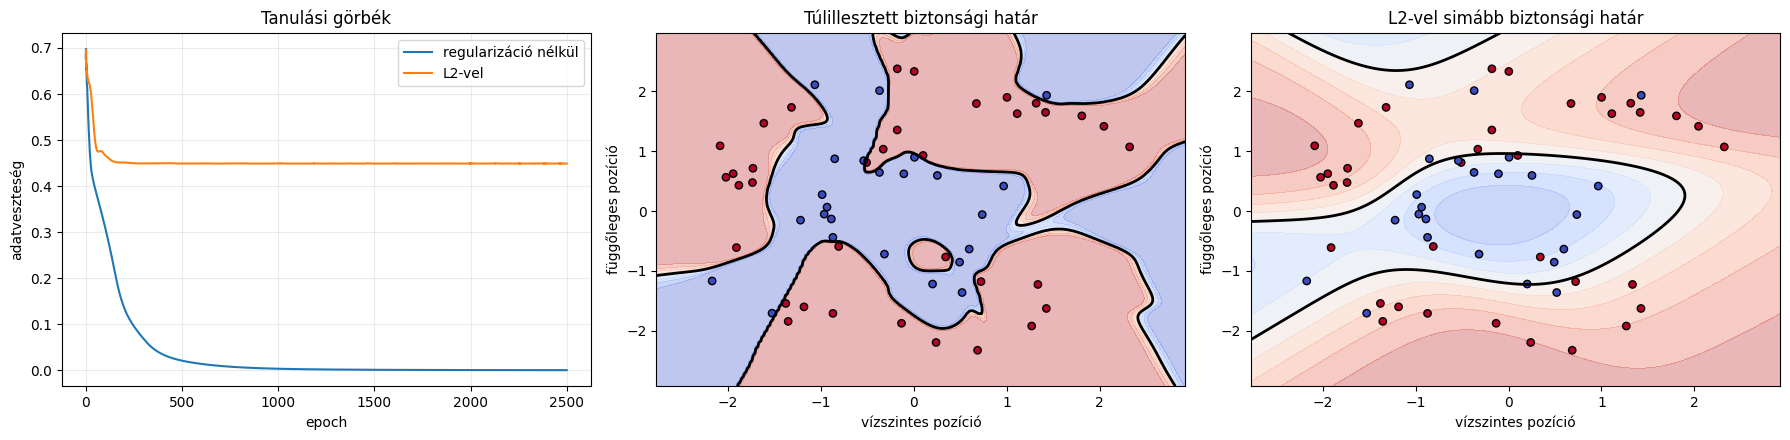

In [61]:
# A NumPy -> Tensor konverzió megőrzi az alakokat.
X_small_t = torch.from_numpy(X_small_train)  # (60, 2)
y_noisy_t = torch.from_numpy(y_noisy_train)  # (60,)
X_test_t = torch.from_numpy(X_clean_test)  # (1000, 2)
y_test_t = torch.from_numpy(y_clean_test)  # (1000,)


def make_large_one_layer_model():
    """A kevés adathoz képest szándékosan nagy kapacitású háló."""
    return nn.Sequential(
        nn.Linear(2, 128),  # (N, 2) -> (N, 128)
        nn.Tanh(),          # (N, 128) -> (N, 128)
        nn.Linear(128, 1),  # (N, 128) -> (N, 1) logit
    )

# Azonos kezdőállapot teszi összehasonlíthatóvá a két kísérletet.
torch.manual_seed(7)
overfit_model = make_large_one_layer_model()
regularized_model = make_large_one_layer_model()
regularized_model.load_state_dict(overfit_model.state_dict())

overfit_losses = train_binary_model(
    overfit_model, X_small_t, y_noisy_t,
    epochs=2500, learning_rate=0.02, weight_decay=0.0
)
regularized_losses = train_binary_model(
    regularized_model, X_small_t, y_noisy_t,
    epochs=2500, learning_rate=0.02, weight_decay=0.01
)

results = {
    "Regularizáció nélkül": (
        binary_accuracy(overfit_model, X_small_t, y_noisy_t),
        binary_accuracy(overfit_model, X_test_t, y_test_t),
    ),
    "L2-regularizációval": (
        binary_accuracy(regularized_model, X_small_t, y_noisy_t),
        binary_accuracy(regularized_model, X_test_t, y_test_t),
    ),
}
for name, (train_accuracy, test_accuracy) in results.items():
    print(f"{name:24s} | tanító: {100 * train_accuracy:5.1f}% | teszt: {100 * test_accuracy:5.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(overfit_losses, label="regularizáció nélkül")
axes[0].plot(regularized_losses, label="L2-vel")
axes[0].set(xlabel="epoch", ylabel="adatveszteség", title="Tanulási görbék")
axes[0].legend()
axes[0].grid(alpha=0.25)
plot_decision_surface(
    overfit_model,
    X_small_train,
    y_noisy_train,
    "Túlillesztett biztonsági határ",
    axes[1],
    xlabel="vízszintes pozíció",
    ylabel="függőleges pozíció",
)
plot_decision_surface(
    regularized_model,
    X_small_train,
    y_noisy_train,
    "L2-vel simább biztonsági határ",
    axes[2],
    xlabel="vízszintes pozíció",
    ylabel="függőleges pozíció",
)
plt.tight_layout()
plt.show()

## 3.3 Többosztályos osztályozás: MNIST és softmax

Az MNIST 28×28 pixeles, szürkeárnyalatos képeket és a hozzájuk tartozó 0–9 számjegycímkéket tartalmazza. Egy kép így $28\cdot28=784$ bemeneti jellemzővé lapítható.

Tíz osztályhoz a háló tíz logitot ad vissza. A **softmax** ezeket nemnegatív, egyre összegző valószínűségekké alakítja:

$$p_k=\frac{e^{z_k}}{\sum_{j=1}^{10}e^{z_j}}.$$

A legnagyobb logithoz és a legnagyobb softmax-valószínűséghez ugyanaz az osztály tartozik. Először letöltjük és megjelenítjük az adatokat; a modellt csak ezután hozzuk létre.

Dokumentáció:

- [`torchvision.datasets.MNIST`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html)
- [`torch.utils.data.DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader)
- [`torch.nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
- [`torch.nn.CrossEntropyLoss`](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
- [`torch.softmax`](https://pytorch.org/docs/stable/generated/torch.softmax.html)

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



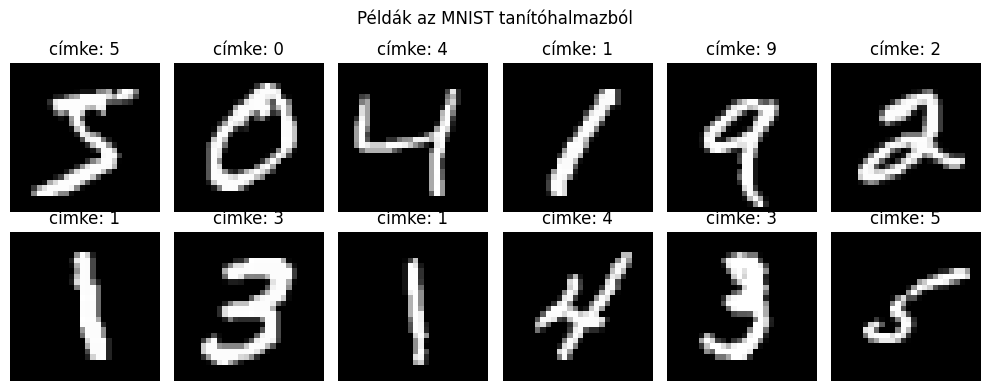

Tanítóminták: 60000, tesztminták: 10000
Egy kép tenzoralakja: torch.Size([1, 28, 28])


In [57]:
# A ToTensor a 28 x 28 képet float32 tenzorrá alakítja és csatornadimenziót ad:
# (28, 28) -> (1, 28, 28), a pixelértékeket pedig a [0, 1] tartományba skálázza.
mnist_transform = transforms.ToTensor()
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=mnist_transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=mnist_transform)

# Egy tanító batch alakja (256, 1, 28, 28), a címkéké (256,).
train_loader = DataLoader(mnist_train, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
# Egy teszt batch alakja legfeljebb (512, 1, 28, 28), a címkéké legfeljebb (512,).
test_loader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

# Az első 12 képet a címkéjükkel együtt nézzük meg a modell illesztése előtt.
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for index, axis in enumerate(axes.ravel()):
    image, label = mnist_train[index]  # image: (1, 28, 28), label: skalár
    axis.imshow(image.squeeze(0), cmap="gray")  # (1, 28, 28) -> (28, 28)
    axis.set_title(f"címke: {label}")
    axis.axis("off")
plt.suptitle("Példák az MNIST tanítóhalmazból")
plt.tight_layout()
plt.show()

print(f"Tanítóminták: {len(mnist_train)}, tesztminták: {len(mnist_test)}")
print(f"Egy kép tenzoralakja: {mnist_train[0][0].shape}")

A tanítás során **nem teszünk softmax réteget a modell végére**. A `CrossEntropyLoss` stabil módon maga egyesíti a `log_softmax` műveletet és a negatív log-likelihood veszteséget. Ezért közvetlenül a logitokat és az egész számként tárolt címkéket kapja meg.

A modellnek továbbra is pontosan egy rejtett rétege van. A `Flatten` a képeket 784 elemű vektorrá alakítja, a ReLU pedig nemlinearitást visz a modellbe.

1. epoch | veszteség: 0.7769 | tesztpontosság: 89.45%
2. epoch | veszteség: 0.3537 | tesztpontosság: 91.27%
3. epoch | veszteség: 0.3042 | tesztpontosság: 92.02%
4. epoch | veszteség: 0.2734 | tesztpontosság: 92.91%
5. epoch | veszteség: 0.2475 | tesztpontosság: 93.39%


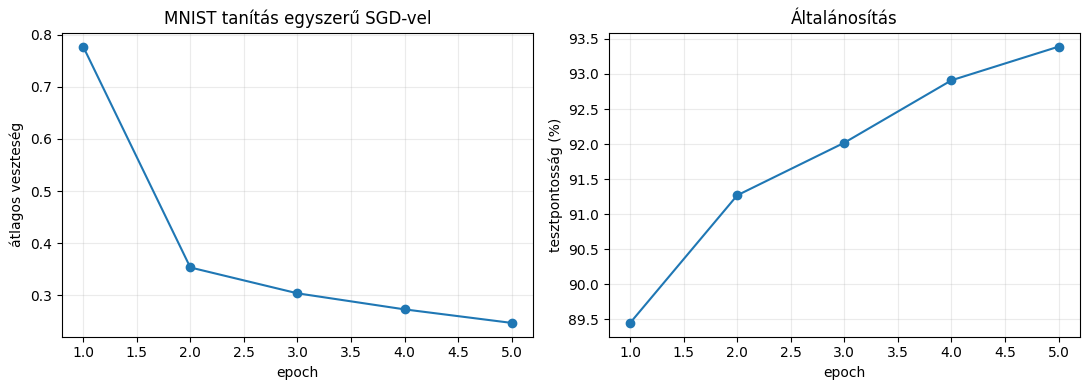

In [62]:
torch.manual_seed(42)
mnist_model = nn.Sequential(
    nn.Flatten(),             # (B, 1, 28, 28) -> (B, 784)
    nn.Linear(28 * 28, 128), # (B, 784) -> (B, 128)
    nn.ReLU(),                # (B, 128) -> (B, 128)
    nn.Linear(128, 10),       # (B, 128) -> (B, 10) logit
).to(device)

mnist_criterion = nn.CrossEntropyLoss()
# Egyelőre egyszerű SGD-t használunk; az Adam optimalizálót a választható részben vezetjük be.
mnist_optimizer = torch.optim.SGD(mnist_model.parameters(), lr=0.1)
mnist_epoch_losses = []
mnist_test_accuracies = []

for epoch in range(5):
    mnist_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        # images: (B, 1, 28, 28), labels: (B,); B az utolsó batchben kisebb lehet.
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = mnist_model(images)  # (B, 1, 28, 28) -> (B, 10)
        loss = mnist_criterion(logits, labels)  # (B, 10) és (B,) -> skalár
        mnist_optimizer.zero_grad()
        loss.backward()
        mnist_optimizer.step()
        running_loss += loss.item() * images.size(0)

    # Értékeléskor nincs szükség gradiensre és a paramétereket sem módosítjuk.
    mnist_model.eval()
    correct = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)  # (B, 1, 28, 28)
            labels = labels.to(device, non_blocking=True)  # (B,)
            predicted_labels = mnist_model(images).argmax(dim=1)  # (B, 10) -> (B,)
            correct += (predicted_labels == labels).sum().item()

    epoch_loss = running_loss / len(mnist_train)
    test_accuracy = correct / len(mnist_test)
    mnist_epoch_losses.append(epoch_loss)
    mnist_test_accuracies.append(test_accuracy)
    print(f"{epoch + 1}. epoch | veszteség: {epoch_loss:.4f} | tesztpontosság: {100 * test_accuracy:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, 6), mnist_epoch_losses, marker="o")
axes[0].set(xlabel="epoch", ylabel="átlagos veszteség", title="MNIST tanítás egyszerű SGD-vel")
axes[1].plot(range(1, 6), np.array(mnist_test_accuracies) * 100, marker="o")
axes[1].set(xlabel="epoch", ylabel="tesztpontosság (%)", title="Általánosítás")
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

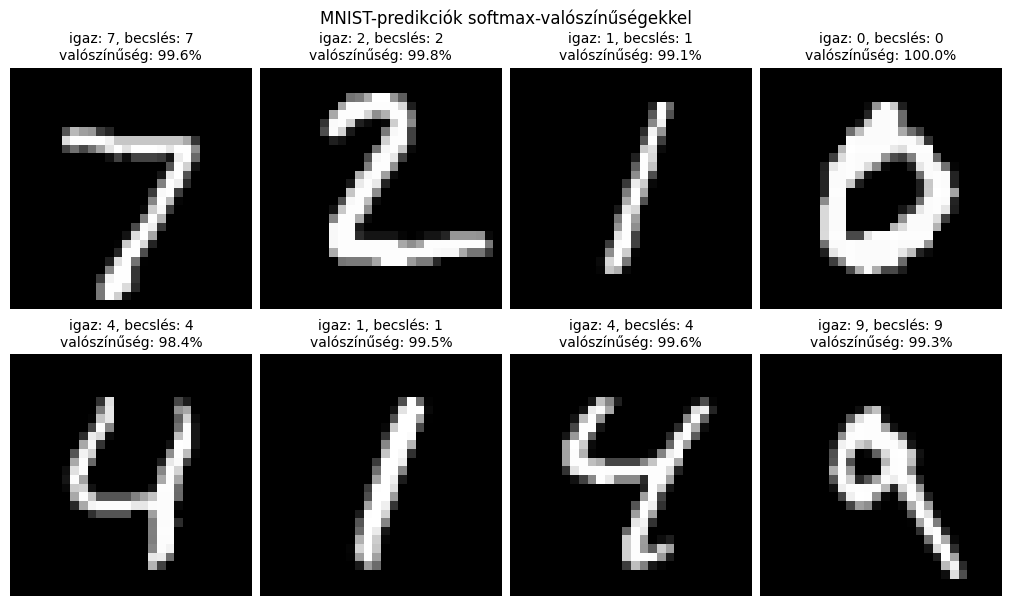

Az első minta valószínűségeinek összege: 0.9999998807907104


In [59]:
mnist_model.eval()
images, labels = next(iter(test_loader))  # legfeljebb (512, 1, 28, 28), illetve (512,)
images_device = images.to(device)  # az alak nem változik, csak az eszköz

with torch.no_grad():
    logits = mnist_model(images_device)  # (B, 1, 28, 28) -> (B, 10)
    probabilities = torch.softmax(logits, dim=1).cpu()  # (B, 10), soronként 1 az összeg
    predicted_labels = probabilities.argmax(dim=1)  # (B, 10) -> (B,)

# Az első nyolc tesztképen a legnagyobb softmax-valószínűséget is kiírjuk.
fig, axes = plt.subplots(2, 4, figsize=(10, 6), constrained_layout=True)
for index, axis in enumerate(axes.ravel()):
    predicted_class = predicted_labels[index].item()  # skalár tenzor -> Python egész
    confidence = probabilities[index, predicted_class].item()  # skalár tenzor -> Python float
    axis.imshow(images[index].squeeze(0), cmap="gray")  # (1, 28, 28) -> (28, 28)
    axis.set_title(
        f"igaz: {labels[index].item()}, becslés: {predicted_class}\n"
        f"valószínűség: {confidence:.1%}",
        fontsize=10,
        pad=6,
    )
    axis.axis("off")
fig.suptitle("MNIST-predikciók softmax-valószínűségekkel")
plt.show()

print("Az első minta valószínűségeinek összege:", probabilities[0].sum().item())

---

# 4. Jó tudni

Az eddigi egyszerű SGD-modell öt epoch után közvetlen összehasonlítási alapot ad. A következő módszerek nem szükségesek a notebook fő gondolatmenetéhez, de gyakran megjelennek gyakorlati neurálisháló-projektekben.

Az összehasonlíthatóság érdekében minden változat ugyanazt az MNIST tanító- és teszthalmazt, 128 rejtett neuront, véletlen magot és öt epochos tanítási keretet használ. Egyszerre csak a vizsgált adat-előkészítést, optimalizálót, ütemezést vagy réteget változtatjuk.

## 4.1 Az adatok normalizálása

A normalizálás egy jellemzőt tipikusan nulla átlagú és egységnyi szórású skálára hoz:

$$x_{norm}=\frac{x-\mu}{\sigma}.$$

Ez javíthatja az optimalizálás numerikus viselkedését, mert a bemenetek hasonló skálán vannak. A $\mu$ és $\sigma$ értékeket kizárólag a **tanítóhalmazból** szabad becsülni; a teszthalmaz bevonása adatszivárgás lenne.

Az MNIST gyakran használt tanítóhalmaz-statisztikái $\mu=0{,}1307$ és $\sigma=0{,}3081$. A [`torchvision.transforms.Normalize`](https://pytorch.org/vision/stable/generated/torchvision.transforms.Normalize.html) csatornánként végzi el a transzformációt. A normalizálás adat-előkészítés, nem tanulható réteg és nem regularizáció.

Nyers batch:       átlag=0.129, szórás=0.307
Normalizált batch: átlag=0.005, szórás=1.008


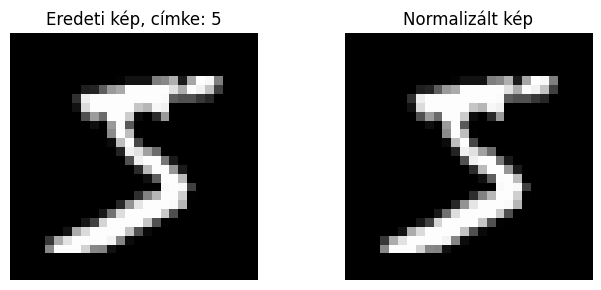

In [63]:
mnist_mean = (0.1307,)
mnist_std = (0.3081,)
normalized_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std),
])

normalized_train = datasets.MNIST(
    root="./data", train=True, download=False, transform=normalized_transform
)
normalized_test = datasets.MNIST(
    root="./data", train=False, download=False, transform=normalized_transform
)
normalized_train_loader = DataLoader(
    normalized_train, batch_size=256, shuffle=True, num_workers=2, pin_memory=True
)
normalized_test_loader = DataLoader(
    normalized_test, batch_size=512, shuffle=False, num_workers=2, pin_memory=True
)

raw_batch, _ = next(iter(train_loader))  # (256, 1, 28, 28)
normalized_batch, _ = next(iter(normalized_train_loader))  # (256, 1, 28, 28)
print(f"Nyers batch:       átlag={raw_batch.mean():.3f}, szórás={raw_batch.std():.3f}")
print(f"Normalizált batch: átlag={normalized_batch.mean():.3f}, szórás={normalized_batch.std():.3f}")

raw_image, raw_label = mnist_train[0]
normalized_image, _ = normalized_train[0]
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(raw_image.squeeze(0), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Eredeti kép, címke: {raw_label}")
axes[1].imshow(normalized_image.squeeze(0), cmap="gray")
axes[1].set_title("Normalizált kép")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

In [64]:
def make_mnist_baseline():
    """Az előző MNIST-modell új, azonos szerkezetű példánya."""
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    ).to(device)


def run_mnist_experiment(name, model, optimizer, training_loader, evaluation_loader, epochs=5, scheduler=None):
    """Egy MNIST-változat tanítása azonos kiértékelési protokollal."""
    losses = []
    accuracies = []
    learning_rates = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in training_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)  # (B, 1, 28, 28) -> (B, 10)
            loss = mnist_criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in evaluation_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                correct += (model(images).argmax(dim=1) == labels).sum().item()

        losses.append(running_loss / len(training_loader.dataset))
        accuracies.append(correct / len(evaluation_loader.dataset))
        learning_rates.append(optimizer.param_groups[0]["lr"])
        if scheduler is not None:
            scheduler.step()

        print(
            f"{name:24s} | {epoch + 1}. epoch | "
            f"veszteség: {losses[-1]:.4f} | pontosság: {100 * accuracies[-1]:.2f}%"
        )

    return {"loss": losses, "accuracy": accuracies, "learning_rate": learning_rates}


# Csak a bemeneti normalizálás változik; a modell és az SGD beállítása azonos.
torch.manual_seed(42)
normalized_model = make_mnist_baseline()
normalized_optimizer = torch.optim.SGD(normalized_model.parameters(), lr=0.1)
normalized_results = run_mnist_experiment(
    "Normalizálás + SGD",
    normalized_model,
    normalized_optimizer,
    normalized_train_loader,
    normalized_test_loader,
)

Normalizálás + SGD       | 1. epoch | veszteség: 0.4227 | pontosság: 92.70%
Normalizálás + SGD       | 2. epoch | veszteség: 0.2220 | pontosság: 94.68%
Normalizálás + SGD       | 3. epoch | veszteség: 0.1687 | pontosság: 95.46%
Normalizálás + SGD       | 4. epoch | veszteség: 0.1385 | pontosság: 96.27%
Normalizálás + SGD       | 5. epoch | veszteség: 0.1166 | pontosság: 96.70%


## 4.2 Momentum, RMSProp és Adam

Az egyszerű SGD mindig az aktuális minibatch gradiensét követi. Zajos vagy eltérő görbületű irányok esetén ez cikcakkos haladást okozhat.

**SGD momentummal.** A momentum a korábbi gradiensek exponenciális mozgóátlagát tartja fenn:

$$m_t=\beta_1m_{t-1}+(1-\beta_1)g_t,$$

majd a paramétert ennek irányában módosítja. Ez tehetetlenséget ad a tartósan hasznos irányoknak, és csökkenti az oda-vissza oszcillációt. PyTorchban ezt a [`torch.optim.SGD`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) `momentum` argumentuma kapcsolja be.

**RMSProp.** Az RMSProp a gradiensek négyzetének mozgóátlagát követi:

$$v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2,$$

és minden paraméter tanulási lépését $1/(\sqrt{v_t}+\varepsilon)$ tényezővel skálázza. A gyakran nagy gradienst kapó paraméterek kisebb, a ritkán frissülők nagyobb lépést kapnak. Dokumentáció: [`torch.optim.RMSprop`](https://pytorch.org/docs/stable/generated/torch.optim.RMSprop.html).

**Adam.** Az Adam az első momentumot és az RMSProp-szerű második momentumot együtt, torzításkorrekcióval használja:

$$\theta_{t+1}=\theta_t-\eta\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\varepsilon}.$$

Ez gyakran kevesebb kézi hangolással tanul gyorsan, de nem garantál minden feladaton jobb általánosítást az SGD-nél. Dokumentáció: [`torch.optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html).

In [65]:
# Ugyanaz a nyers adat, architektúra, seed és öt epoch; csak az optimalizáló változik.
torch.manual_seed(42)
adam_model = make_mnist_baseline()
adam_optimizer = torch.optim.Adam(adam_model.parameters(), lr=1e-3)
adam_results = run_mnist_experiment(
    "Adam",
    adam_model,
    adam_optimizer,
    train_loader,
    test_loader,
)

Adam                     | 1. epoch | veszteség: 0.5167 | pontosság: 92.34%
Adam                     | 2. epoch | veszteség: 0.2403 | pontosság: 94.16%
Adam                     | 3. epoch | veszteség: 0.1819 | pontosság: 95.16%
Adam                     | 4. epoch | veszteség: 0.1460 | pontosság: 95.96%
Adam                     | 5. epoch | veszteség: 0.1218 | pontosság: 96.22%


## 4.3 Tanulásiráta-csökkentés és ütemezés

A nagy tanulási ráta kezdetben gyors haladást tesz lehetővé, az optimum közelében viszont túl nagy lépéseket és ingadozást okozhat. A **learning rate decay** a tanítás során fokozatosan csökkenti a tanulási rátát.

Az ütemező (`scheduler`) szabályozza, mikor és hogyan változzon az érték. Gyakori stratégiák:

- lépcsőzetes csökkentés;
- exponenciális csökkentés;
- koszinuszos ütemezés;
- validációs metrika stagnálására reagáló csökkentés.

A [`torch.optim.lr_scheduler.StepLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html) minden `step_size` epoch után `gamma`-szorosára csökkenti a rátát. Az `optimizer.step()` továbbra is minden minibatch után, a `scheduler.step()` pedig itt minden epoch végén fut.

SGD + StepLR             | 1. epoch | veszteség: 0.5778 | pontosság: 91.01%
SGD + StepLR             | 2. epoch | veszteség: 0.2934 | pontosság: 92.66%
SGD + StepLR             | 3. epoch | veszteség: 0.2443 | pontosság: 93.30%
SGD + StepLR             | 4. epoch | veszteség: 0.2237 | pontosság: 93.94%
SGD + StepLR             | 5. epoch | veszteség: 0.2074 | pontosság: 94.00%


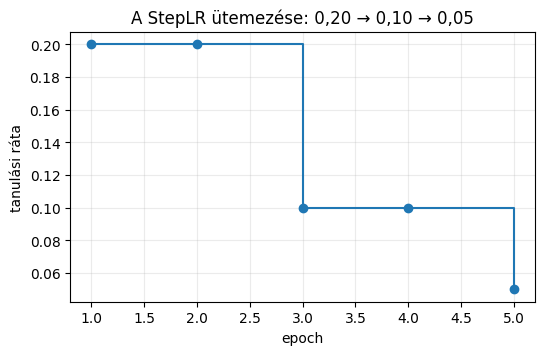

In [66]:
torch.manual_seed(42)
scheduled_model = make_mnist_baseline()
scheduled_optimizer = torch.optim.SGD(scheduled_model.parameters(), lr=0.2)
scheduler = torch.optim.lr_scheduler.StepLR(
    scheduled_optimizer, step_size=2, gamma=0.5
)
scheduled_results = run_mnist_experiment(
    "SGD + StepLR",
    scheduled_model,
    scheduled_optimizer,
    train_loader,
    test_loader,
    scheduler=scheduler,
)

plt.figure(figsize=(6, 3.5))
plt.step(
    range(1, 6), scheduled_results["learning_rate"], where="post", marker="o"
)
plt.xlabel("epoch")
plt.ylabel("tanulási ráta")
plt.title("A StepLR ütemezése: 0,20 → 0,10 → 0,05")
plt.grid(alpha=0.25)
plt.show()

Ebben a rövid futásban az ütemezett modell 94,00%-ot ér el, vagyis kissé jobb a 93,39%-os alap-SGD-nél, de gyengébb az Adamnál és a normalizált változatnál. Az ütemezés alakja és kezdő rátája hangolandó hiperparaméter; önmagában nem garantál javulást.

## 4.4 Dropout

A [`torch.nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) tanításkor minden aktivációt `p` valószínűséggel nullára állít, a megmaradó értékeket pedig megfelelően átskálázza. Így a háló nem támaszkodhat mindig ugyanarra a néhány neuronra.

A Dropout **regularizációs módszer**: célja a túlillesztés mérséklése, nem feltétlenül a tanítási pontosság növelése. Kiértékeléskor a `model.eval()` kikapcsolja, ezért ugyanaz a bemenet determinisztikus kimenetet ad. Kis, egyszerű modellen vagy rövid tanításnál akár kissé ronthatja is a teszteredményt.

In [67]:
torch.manual_seed(42)
dropout_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),  # tanításkor a (B, 128) aktivációk 30%-át nullázza
    nn.Linear(128, 10),
).to(device)
dropout_optimizer = torch.optim.SGD(dropout_model.parameters(), lr=0.1)
dropout_results = run_mnist_experiment(
    "SGD + Dropout",
    dropout_model,
    dropout_optimizer,
    train_loader,
    test_loader,
)

SGD + Dropout            | 1. epoch | veszteség: 0.8461 | pontosság: 89.36%
SGD + Dropout            | 2. epoch | veszteség: 0.4077 | pontosság: 91.36%
SGD + Dropout            | 3. epoch | veszteség: 0.3441 | pontosság: 92.42%
SGD + Dropout            | 4. epoch | veszteség: 0.3009 | pontosság: 93.28%
SGD + Dropout            | 5. epoch | veszteség: 0.2705 | pontosság: 93.81%


## 4.5 Batch Normalization

A [`torch.nn.BatchNorm1d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html) minibatchenként standardizálja egy rejtett réteg jellemzőit, majd tanulható $\gamma$ skálázást és $\beta$ eltolást alkalmaz:

$$\hat{h}=\frac{h-\mu_B}{\sqrt{\sigma_B^2+\varepsilon}},\qquad y=\gamma\hat{h}+\beta.$$

Eredeti motivációja az [**internal covariate shift**](https://medium.com/analytics-vidhya/internal-covariate-shift-an-overview-of-how-to-speed-up-neural-network-training-3e2a3dcdd5cc) csökkentése volt: miközben az előző rétegek tanulnak, a következő réteg bemeneti aktivációinak eloszlása folyamatosan változik. A BatchNorm stabilabb skálán tartja ezeket az aktivációkat, így gyakran nagyobb tanulási ráta és gyorsabb optimalizálás lehetséges. A modern kutatások szerint előnye nem kizárólag az eloszláseltolódás csökkentéséből ered; a simább optimalizálási felület is fontos magyarázat.

A BatchNorm **nem regularizációs módszer**. A minibatch-statisztikák okozhatnak mellékes zajhatást, de elsődleges célja az aktivációk normalizálása és az optimalizálás stabilizálása. Tanításkor batch-statisztikákat és futó átlagokat használ, míg `model.eval()` módban a megtanult futó statisztikákból számol.

In [68]:
torch.manual_seed(42)
batchnorm_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),  # (B, 784) -> (B, 128)
    nn.BatchNorm1d(128),      # a 128 rejtett jellemzőt külön normalizálja
    nn.ReLU(),
    nn.Linear(128, 10),
).to(device)
batchnorm_optimizer = torch.optim.SGD(batchnorm_model.parameters(), lr=0.1)
batchnorm_results = run_mnist_experiment(
    "SGD + BatchNorm",
    batchnorm_model,
    batchnorm_optimizer,
    train_loader,
    test_loader,
)

SGD + BatchNorm          | 1. epoch | veszteség: 0.3833 | pontosság: 94.23%
SGD + BatchNorm          | 2. epoch | veszteség: 0.1958 | pontosság: 95.43%
SGD + BatchNorm          | 3. epoch | veszteség: 0.1506 | pontosság: 95.99%
SGD + BatchNorm          | 4. epoch | veszteség: 0.1246 | pontosság: 96.68%
SGD + BatchNorm          | 5. epoch | veszteség: 0.1065 | pontosság: 96.89%


## 4.6 A módszerek együttes használata

Végül egyetlen modellben kombináljuk az eddig külön vizsgált módszereket:

- normalizált MNIST-bemenet;
- BatchNorm a rejtett lineáris réteg után;
- ReLU és Dropout a rejtett aktivációkon;
- Adam optimalizáló;
- StepLR tanulásiráta-ütemezés.

A módszerek hatása nem feltétlenül adódik össze: például a BatchNorm és a bemeneti normalizálás más helyen avatkozik be, a Dropout pedig szándékosan zajt visz a tanításba. Ezért a kombinációt ugyanazzal az ötepochos protokollal mérjük meg, nem feltételezzük automatikusan, hogy minden különálló változatnál jobb lesz.

In [70]:
torch.manual_seed(42)
combined_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),  # (B, 784) -> (B, 128)
    nn.BatchNorm1d(128),      # a rejtett aktivációk batch-normalizálása
    nn.ReLU(),
    nn.Dropout(p=0.3),        # tanításkor a rejtett aktivációk 30%-át nullázza
    nn.Linear(128, 10),
).to(device)

combined_optimizer = torch.optim.Adam(combined_model.parameters(), lr=1e-3)
combined_scheduler = torch.optim.lr_scheduler.StepLR(
    combined_optimizer, step_size=2, gamma=0.5
)
combined_results = run_mnist_experiment(
    "Kombinált modell",
    combined_model,
    combined_optimizer,
    normalized_train_loader,  # bemeneti normalizálás
    normalized_test_loader,
    scheduler=combined_scheduler,
)

print("Használt tanulási ráták:", combined_results["learning_rate"])

Kombinált modell         | 1. epoch | veszteség: 0.4395 | pontosság: 94.07%
Kombinált modell         | 2. epoch | veszteség: 0.2192 | pontosság: 95.78%
Kombinált modell         | 3. epoch | veszteség: 0.1704 | pontosság: 96.27%
Kombinált modell         | 4. epoch | veszteség: 0.1513 | pontosság: 96.70%
Kombinált modell         | 5. epoch | veszteség: 0.1339 | pontosság: 96.91%
Használt tanulási ráták: [0.001, 0.001, 0.0005, 0.0005, 0.00025]


## 4.7 Az MNIST-változatok összehasonlítása

Az eredmények ugyanazon tanító- és teszthalmazra, architektúraméretre, véletlen magra és öt epochra vonatkoznak. Ez egy szemléltető, rövid kísérlet: az eltérések nem általános rangsort jelentenek, és más hiperparaméterekkel változhatnak.

A kombinált modell 96,91%-ot ér el, de az előnye a 96,89%-os BatchNorm-változathoz képest elhanyagolható. Ez jól mutatja, hogy több technika együttes használata nem jelent automatikusan összeadódó javulást.

Változat                  | 5. epoch tesztpontossága
------------------------------------------------------
Alap SGD                  |  93.39%
Normalizálás + SGD        |  96.70%
Adam                      |  96.22%
SGD + StepLR              |  94.00%
SGD + Dropout             |  93.81%
SGD + BatchNorm           |  96.89%
Mind együtt               |  96.91%


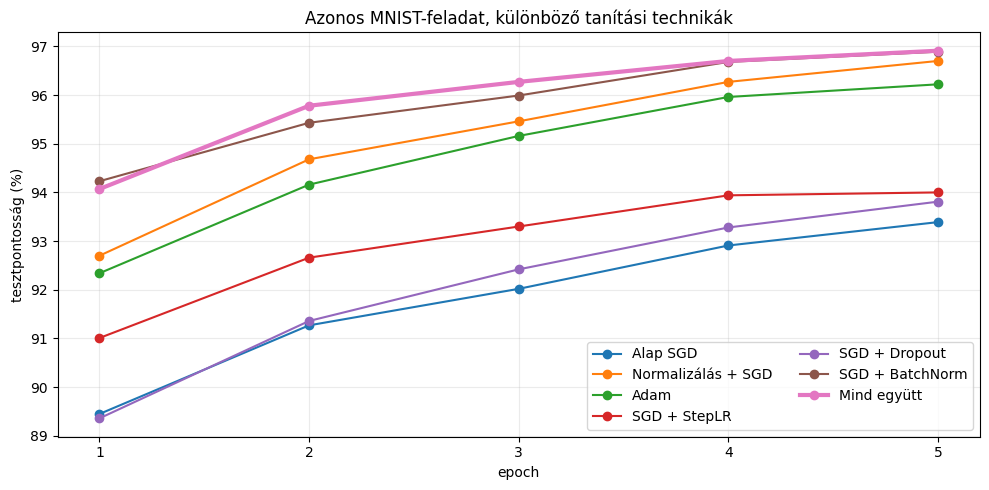

In [71]:
comparison_results = {
    "Alap SGD": mnist_test_accuracies,
    "Normalizálás + SGD": normalized_results["accuracy"],
    "Adam": adam_results["accuracy"],
    "SGD + StepLR": scheduled_results["accuracy"],
    "SGD + Dropout": dropout_results["accuracy"],
    "SGD + BatchNorm": batchnorm_results["accuracy"],
    "Mind együtt": combined_results["accuracy"],
}

print("Változat                  | 5. epoch tesztpontossága")
print("-" * 54)
for name, accuracies in comparison_results.items():
    print(f"{name:26s}| {100 * accuracies[-1]:6.2f}%")

plt.figure(figsize=(10, 5))
for name, accuracies in comparison_results.items():
    line_width = 3 if name == "Mind együtt" else 1.5
    plt.plot(
        range(1, 6),
        np.array(accuracies) * 100,
        marker="o",
        linewidth=line_width,
        label=name,
    )
plt.xlabel("epoch")
plt.ylabel("tesztpontosság (%)")
plt.title("Azonos MNIST-feladat, különböző tanítási technikák")
plt.xticks(range(1, 6))
plt.grid(alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

---

# Összefoglalás

1. A lineáris regresszióban az MSE minimuma egyszerű esetben analitikusan is meghatározható.
2. A PyTorch-tenzorok alakja leírja a minták, jellemzők és kimenetek dimenzióit; az automatikus deriváláshoz a tanulható paramétereken `requires_grad=True` szükséges.
3. A gradiens módszer iteratívan keresi az optimumot, és összetett modellekre is alkalmazható.
4. A vektorizáció sok minta és jellemző egyidejű, hatékony feldolgozását teszi lehetővé.
5. Lineáris logisztikus regressziónál a BCE konvex a paraméterekben, míg a szigmoiddal összetett MSE általában nem konvex és telített állapotban eltűnő gradienst okozhat.
6. A logisztikus regresszió lineáris döntési határt tanul, ezért nem old meg minden osztályozási feladatot.
7. Egy nemlineáris aktivációt tartalmazó rejtett réteg már görbült döntési határt is képes létrehozni.
8. A nagyobb kapacitás nem mindig jobb: kevés, zajos adaton túlillesztéshez vezethet.
9. Az L2-regularizáció egyszerűbb súlyokat és gyakran jobb általánosítást eredményez.
10. Többosztályos feladatban a softmax valószínűségi eloszlássá alakítja a logitokat.
11. A bemenet normalizálása javíthatja az optimalizálás kondicionálását.
12. Az Adam momentumot és RMSProp-szerű adaptív skálázást egyesít.
13. A tanulásiráta-ütemezés a tanítás különböző szakaszaihoz igazítja a lépésméretet.
14. A Dropout regularizáció, míg a BatchNorm az aktivációkat normalizáló és az optimalizálást stabilizáló réteg, nem regularizáció.

# Önálló feladatok

## 1. Tanulási ráta

Változtasd meg az egyszerű regresszió [`torch.optim.SGD`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) tanulási rátáját 0,005-re és 0,5-re. Mit tapasztalsz?

**Kapcsolódó korábbi rész:** a 9. cella ismerteti a gradiens módszert, a 10. cella pedig az SGD tanítását és a költségfelületen bejárt útvonalat mutatja.

Double-click <b>here</b> for the solution.

<!--
def train_with_learning_rate(learning_rate, epochs=300):
    w_trial = torch.zeros(1, requires_grad=True)
    b_trial = torch.zeros(1, requires_grad=True)
    optimizer_trial = torch.optim.SGD([w_trial, b_trial], lr=learning_rate)
    losses = []
    for _ in range(epochs):
        loss = criterion_mse(w_trial * x_t + b_trial, y_t)
        optimizer_trial.zero_grad()
        loss.backward()
        optimizer_trial.step()
        losses.append(loss.item())
    return losses

for learning_rate in [0.005, 0.5]:
    plt.plot(train_with_learning_rate(learning_rate), label=f"lr={learning_rate}")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()
# A 0,005 lassabban konvergál. A 0,5 ezen a feladaton túl nagy, ezért instabillá válhat.
-->

## 2. Negyedik regressziós jellemző

Adj egy negyedik jellemzőt a többváltozós regresszióhoz, és módosítsd a [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) réteget.

**Kapcsolódó korábbi rész:** a 11. cella vezeti be a vektorizált többváltozós regressziót, a 12–14. cella pedig az adatok előállítását és a `Linear` réteg tanítását mutatja.

Double-click <b>here</b> for the solution.

<!--
extra_feature = np.random.normal(size=(n_samples, 1)).astype(np.float32)
X_multi_4 = np.column_stack([X_multi, extra_feature])  # (200, 4)
true_weights_4 = np.array([3.0, -2.0, 0.5, 1.5], dtype=np.float32)
y_multi_4 = X_multi_4 @ true_weights_4 + 1.2 + np.random.normal(0, 0.5, n_samples)
X_multi_4_t = torch.from_numpy(X_multi_4)
y_multi_4_t = torch.tensor(y_multi_4, dtype=torch.float32).reshape(-1, 1)
model_4 = nn.Linear(4, 1)
optimizer_4 = torch.optim.SGD(model_4.parameters(), lr=0.05)
for _ in range(300):
    loss = criterion_mse(model_4(X_multi_4_t), y_multi_4_t)
    optimizer_4.zero_grad()
    loss.backward()
    optimizer_4.step()
print(model_4.weight.detach(), model_4.bias.detach())
-->

## 3. Másik irány a konvexitási ábrán

Válassz másik $\mathbf{d}$ irányt a konvexitási ábrán. Találsz negatív MSE-görbületet? Vesd össze a számítást a [`binary_cross_entropy_with_logits`](https://pytorch.org/docs/stable/generated/torch.nn.functional.binary_cross_entropy_with_logits.html) dokumentációjával.

**Kapcsolódó korábbi rész:** a 17–19. cella hasonlítja össze az MSE és BCE tulajdonságait, a 20–21. cella pedig az egydimenziós veszteségmetszetet és annak görbületét vezeti le.

Double-click <b>here</b> for the solution.

<!--
direction_trial = torch.tensor([1.0, -0.5])
direction_trial = direction_trial / direction_trial.norm()
scores_trial = X_sep_t @ direction_trial
logits_trial = alphas[:, None] * scores_trial[None, :]
probabilities_trial = torch.sigmoid(logits_trial)
derivative_trial = probabilities_trial * (1 - probabilities_trial)
mse_curvature_trial = (
    2 * scores_trial[None, :] ** 2
    * (
        derivative_trial ** 2
        + (probabilities_trial - target_grid)
        * derivative_trial
        * (1 - 2 * probabilities_trial)
    )
).mean(dim=1)
print("Legkisebb MSE-görbület:", mse_curvature_trial.min().item())
# Egyetlen negatív érték elegendő annak bizonyításához, hogy a teljes felület nem konvex.
-->

## 4. Rejtett neuronok száma

Próbálj 2, 4 és 16 rejtett neuront a biztonságizóna-adathalmazon a [`torch.nn.Linear`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) rétegek módosításával. Hogyan változik a döntési határ?

**Kapcsolódó korábbi rész:** a 23–25. cella mutatja be a nem lineárisan szeparálható biztonságizóna-adatokat és a logisztikus regresszió korlátját, a 26–27. cella pedig az egy rejtett rétegű megoldást.

Double-click <b>here</b> for the solution.

<!--
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for hidden_units, axis in zip([2, 4, 16], axes):
    torch.manual_seed(42)
    trial_model = nn.Sequential(
        nn.Linear(2, hidden_units),
        nn.Tanh(),
        nn.Linear(hidden_units, 1),
    )
    train_binary_model(trial_model, X_rings_t, y_rings_t, epochs=1000, learning_rate=0.03)
    accuracy = binary_accuracy(trial_model, X_rings_t, y_rings_t)
    plot_decision_surface(
        trial_model, X_rings, y_rings,
        f"{hidden_units} neuron, pontosság={100 * accuracy:.1f}%", axis,
    )
plt.tight_layout()
plt.show()
-->

## 5. L2-regularizáció erőssége

Vizsgáld meg a [`torch.optim.SGD`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) `weight_decay` argumentumának 0, 0,001, 0,01 és 0,1 értékeit.

**Kapcsolódó korábbi rész:** a 28–29. cella készíti elő a zajos tanító- és tiszta teszthalmazt, a 30–31. cella pedig az L2-regularizációt és a `weight_decay` hatását mutatja be.

Double-click <b>here</b> for the solution.

<!--
for weight_decay in [0.0, 0.001, 0.01, 0.1]:
    torch.manual_seed(7)
    trial_model = make_large_one_layer_model()
    train_binary_model(
        trial_model, X_small_t, y_noisy_t,
        epochs=2500, learning_rate=0.02, weight_decay=weight_decay,
    )
    train_acc = binary_accuracy(trial_model, X_small_t, y_noisy_t)
    test_acc = binary_accuracy(trial_model, X_test_t, y_test_t)
    print(f"weight_decay={weight_decay:.3f}: tanító={train_acc:.1%}, teszt={test_acc:.1%}")
-->

## 6. Eltérő bemeneti normalizálás

Egészítsd ki az MNIST bemeneti transzformációját [`transforms.Normalize`](https://pytorch.org/vision/stable/generated/torchvision.transforms.Normalize.html) használatával, de próbálj másik átlagot vagy szórást. Miért romolhat az eredmény?

**Kapcsolódó korábbi rész:** a 37. cella ismerteti a normalizálást, a 38. cella létrehozza a normalizált MNIST-adathalmazt, a 39. cella pedig betanítja az összehasonlítható modellt.

Double-click <b>here</b> for the solution.

<!--
wrong_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.1,)),
])
wrong_train = datasets.MNIST("./data", train=True, download=False, transform=wrong_transform)
wrong_test = datasets.MNIST("./data", train=False, download=False, transform=wrong_transform)
wrong_train_loader = DataLoader(wrong_train, batch_size=256, shuffle=True)
wrong_test_loader = DataLoader(wrong_test, batch_size=512)
torch.manual_seed(42)
wrong_model = make_mnist_baseline()
wrong_optimizer = torch.optim.SGD(wrong_model.parameters(), lr=0.1)
wrong_results = run_mnist_experiment(
    "Hibás normalizálás", wrong_model, wrong_optimizer,
    wrong_train_loader, wrong_test_loader,
)
# A rossz statisztikák kedvezőtlen skálára és eltolásra vihetik a bemeneteket.
-->

## 7. Optimalizálók összehasonlítása

Hasonlítsd össze az [`torch.optim.Adam`](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html), [`torch.optim.RMSprop`](https://pytorch.org/docs/stable/generated/torch.optim.RMSprop.html) és momentumos [`torch.optim.SGD`](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) optimalizálókat azonos tanulási keretben.

**Kapcsolódó korábbi rész:** a 39. cella tartalmazza a közös MNIST-kísérleti függvényt, a 40. cella ismerteti a momentumot, RMSPropot és Adamot, a 41. cella pedig az Adam-példát futtatja.

Double-click <b>here</b> for the solution.

<!--
optimizer_builders = {
    "Momentum": lambda parameters: torch.optim.SGD(parameters, lr=0.1, momentum=0.9),
    "RMSProp": lambda parameters: torch.optim.RMSprop(parameters, lr=0.001),
    "Adam": lambda parameters: torch.optim.Adam(parameters, lr=0.001),
}
optimizer_results = {}
for name, build_optimizer in optimizer_builders.items():
    torch.manual_seed(42)
    trial_model = make_mnist_baseline()
    trial_optimizer = build_optimizer(trial_model.parameters())
    optimizer_results[name] = run_mnist_experiment(
        name, trial_model, trial_optimizer, train_loader, test_loader,
    )
-->

## 8. StepLR hangolása

Módosítsd a [`StepLR`](https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.StepLR.html) `step_size` és `gamma` értékeit, majd ábrázold a tanulási rátát.

**Kapcsolódó korábbi rész:** a 42. cella magyarázza a tanulásiráta-ütemezést, a 43. cella pedig a `StepLR` konfigurálását, epochonkénti léptetését és ábrázolását mutatja.

Double-click <b>here</b> for the solution.

<!--
torch.manual_seed(42)
trial_model = make_mnist_baseline()
trial_optimizer = torch.optim.SGD(trial_model.parameters(), lr=0.2)
trial_scheduler = torch.optim.lr_scheduler.StepLR(
    trial_optimizer, step_size=1, gamma=0.8,
)
trial_results = run_mnist_experiment(
    "StepLR feladat", trial_model, trial_optimizer,
    train_loader, test_loader, scheduler=trial_scheduler,
)
plt.step(range(1, 6), trial_results["learning_rate"], where="post", marker="o")
plt.xlabel("epoch")
plt.ylabel("tanulási ráta")
plt.show()
-->

## 9. Dropout valószínűsége

Próbáld ki a [`torch.nn.Dropout`](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html) `p=0.1`, `0.3` és `0.5` értékeit. Figyeld meg külön a tanítási és tesztpontosságot.

**Kapcsolódó korábbi rész:** a 44. cella ismerteti a Dropout regularizációs szerepét és a `train()`/`eval()` módok különbségét, a 45. cella pedig a `p=0.3` MNIST-példát tartalmazza.

Double-click <b>here</b> for the solution.

<!--
for dropout_probability in [0.1, 0.3, 0.5]:
    torch.manual_seed(42)
    trial_model = nn.Sequential(
        nn.Flatten(), nn.Linear(784, 128), nn.ReLU(),
        nn.Dropout(dropout_probability), nn.Linear(128, 10),
    ).to(device)
    trial_optimizer = torch.optim.SGD(trial_model.parameters(), lr=0.1)
    result = run_mnist_experiment(
        f"Dropout p={dropout_probability}", trial_model, trial_optimizer,
        train_loader, test_loader,
    )
-->

## 10. BatchNorm helye

Helyezd át a [`torch.nn.BatchNorm1d`](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html) réteget a ReLU után. Változik a tanulási görbe?

**Kapcsolódó korábbi rész:** a 46. cella tárgyalja a BatchNorm működését és azt, hogy miért nem regularizáció, a 47. cella pedig a `Linear → BatchNorm → ReLU` sorrendet valósítja meg.

Double-click <b>here</b> for the solution.

<!--
torch.manual_seed(42)
batchnorm_after_relu = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Linear(128, 10),
).to(device)
trial_optimizer = torch.optim.SGD(batchnorm_after_relu.parameters(), lr=0.1)
result = run_mnist_experiment(
    "ReLU után BatchNorm", batchnorm_after_relu, trial_optimizer,
    train_loader, test_loader,
)
-->

## 11. Másik aktiváció

Cseréld a [`torch.nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) aktivációt [`torch.nn.Tanh`](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html)-ra az MNIST-modellben, és hasonlítsd össze a tanulási görbéket.

**Kapcsolódó korábbi rész:** a 26–27. cella Tanh aktivációval épít nemlineáris hálót, a 34–35. cella pedig a ReLU-t használó MNIST-alapmodellt ismerteti és tanítja.

Double-click <b>here</b> for the solution.

<!--
torch.manual_seed(42)
tanh_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.Tanh(),
    nn.Linear(128, 10),
).to(device)
tanh_optimizer = torch.optim.SGD(tanh_model.parameters(), lr=0.1)
tanh_results = run_mnist_experiment(
    "Tanh", tanh_model, tanh_optimizer, train_loader, test_loader,
)
plt.plot(range(1, 6), np.array(mnist_test_accuracies) * 100, label="ReLU")
plt.plot(range(1, 6), np.array(tanh_results["accuracy"]) * 100, label="Tanh")
plt.xlabel("epoch")
plt.ylabel("tesztpontosság (%)")
plt.legend()
plt.show()
-->